<div style="width: 100%; text-align: center; margin-bottom: 20px;">
  <img src="figures/cabecalho_branco.jpg" alt="Cabeçalho" style="max-width: 100%; height: auto;">
</div>

# A Regularização tipo L1 e L2 aplicada à <br> Regressão Linear

**Autor**: Carlos Gabriel de Oliveira Campos

Professor Dr. **Daniel Roberto Cassar**

Disciplina de **Aprendizado de Máquina**

A regressão linear é uma ferramenta simples e poderosa para nos guiar em problemas regressivos. Contudo, sua simplicidade é vulnerável à colinearidade ou esparsidade dos dados, o que pode comprometer seu desempenho. Nesse contexto, surgem as regularizações L1 e L2 para fundamentar novos métodos regressivos que oferecem alternativas mais consistentes e precisas.  

---

## 📑 Sumário

1. [📈 Uma breve introdução à regressão linear](#intro-regressao-linear)
2. [📺 Pondo em prática: Vendas e publicidade](#pratica-vendas-publicidade)
3. [📊 Regressão linear múltipla](#regressao-multipla)
4. [⚖️ Viés, variância e métodos de encolhimento](#vies-variancia-encolhimento)
5. [🧪 Pondo em prática: Dados sintéticos](#pratica-dados-sinteticos)
6. [🫙 O índice de refração de vidros](#refracao-vidros)
7. [📝 Considerações finais](#consideracoes-finais)
- [🤖 Descrição do uso de IA neste trabalho](#uso-ia-trabalho)
- [📚 Referências](#referencias)
- [🖇️ Apêndice](#apendice)


<span id="intro-regressao-linear"></span>
## 1. 📈 Uma breve introdução à regressão linear 

A Regressão Linear é um algoritmo clássico da estatística que opera ao assumir uma relação linear entre uma ou mais variáveis independentes e uma variável dependente. Em aprendizado de máquina, esse mecanismo pode ser utilizado para *induzir* (criar) modelos preditivos cujo *target* (variável alvo) seja quantitativo e contínuo, sendo útil para as mais diversas áreas, como:
 
- Imóveis: Prever preços de propriedades usando localização, tamanho e outros fatores.
- Finanças: A previsão de preços de ações usando taxas de juros e dados de inflação.
- Agricultura: Estimar a produção de culturas a partir de chuva, temperatura e qualidade do solo.
- E-commerce: Analisar como preço, promoções e estações afetam as vendas [1].

### Regressão Linear Simples

A principal referência para esta seção é o capítulo 3 da referência [2].

Para casos de uma única variável independente, chama-se Regressão Linear Simples a relação matemática entre dados que  pode ser representada pela fórmula **(1.1)**, em que as matrizes-coluna, $Y$ e $X$, representam a resposta quantitativa e a variável de previsão, respectivamente. $\beta_0$ e $\beta_1$ são os coeficientes, sendo o primeiro o *intercepto* - o valor estimado para $Y$ quando todas as variáveis independentes valem 0-, e $\beta_1$, o termo que ajusta as variáveis de X ao valor estimado. Ademais, o termo $\epsilon$ simboliza o vetor-coluna de erro aleatório, cujos valores têm média 0, e simboliza variações naturais e irredutíveis que impedem o modelo de prever com total precisão.


$$
Y = \beta_0 + \beta_1 X + \epsilon \qquad (1.1)
$$

### Estimando os coeficientes

Dado um problema real, é uma grande suposição interpretá-lo como uma relação totalmente linear. Raramente ocorre de esse ser o caso de fato, e por isso $Y$ é em função de $\epsilon$ também, o qual não podemos prever. Dessa forma, a notação $\hat{Y}$ representa a resposta *estimada* por nosso modelo, o qual parte da estimativa de seus coeficientes, $\hat{\beta}_0$ e $\hat{\beta}_1$. Dessa maneira, o modelo de regressão linear simples é formulado como



$$
\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X  \qquad (1.2)
$$



O meio mais prático para essa tarefa é o *Método dos Quadrados Mínimos* $\text{(MQM)}$. Para isso, é necessário o conceito de $\text{RSS}$, do inglês, *soma dos resíduos quadráticos*. Ela funciona como um indicador da precisão do modelo, uma *função de custo*! Sendo que uma menor $\text{RSS}$ implica em uma maior precisão em relação aos dados de treino. O quadrado da diferença entre o valor real e o valor estimado serve para que erros de previsão "para mais" e "para menos" não se cancelem, da mesma forma que penaliza mais severamente erros maiores, enquanto suaviza erros menores. O conjunto dos valores estimados para os coeficientes $\beta_0, \beta_1, \dots, \beta_p$ é escrito como $\hat{\beta}_0, \hat{\beta}_1, \dots \hat{\beta}_p$, e o valor estimado para a i-ésima resposta é denotado por $\hat{y}_i$.


$$
\begin{aligned}
\text{RSS} & = (y_1 - \hat{\beta}_0 - \hat{\beta}_1 x_1)^2 + (y_2 - \hat{\beta}_0 - \hat{\beta}_1 x_2)^2 + \dots + (y_n - \hat{\beta}_0 - \hat{\beta}_1 x_n)^2  \qquad (1.3)\\
& = \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2 \\
& = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{aligned}
$$

Quando aplicamos a derivada parcial em relação a cada coeficiente, podemos encontrar que:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x} \qquad (1.4)
$$

<figure align="center">
  <img src="figures/rss-graphic.png" alt="Representação gráfica da RSS" height=400px>
  <figcaption> <b>Figura 1.1</b> - Representação em contorno e tridimensional da soma dos resíduos quadráticos (RSS).</figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em> [2, p. 73]. A RSS aparece em função dos parâmetros, em que o ponto vermelho corresponde ao par de parâmetros que minimizam a RSS para um certo conjunto de dados.</figcaption>
</figure>

Notamos, assim, que há uma dependência de $\beta_0$ em relação a $\beta_1$, o que não é favorável aos cálculos para estimar o valor dos coeficientes, visto que qualquer mudança em $\beta_1$ irá alterar $\beta_0$. Logo, é interessante centralizar $X$, o que torna a média $\tilde{\bar{x}} = 0$.


$$\tilde{x} = x_i - \bar{x}$$
$$\bar{\tilde{x}} = 0$$

Assim:

$$\hat{\beta}_0 = \bar{y}$$

Portanto, com $\hat{\beta}_0$ constante, ao derivar a equação **(1.3)** em relação a $\hat{\beta}_1$ e igualar a 0, este preditor pode ser calculado em notação matricial a partir de

$$
\hat{\beta_1} = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T Y \qquad (1.5)
$$

de maneira que o resíduo quadrático é minimizado.

<span id="pratica-vendas-publicidade"></span>
## 2. 📺 Pondo em prática: Verificando a relação entre vendas e diferentes meios de publicidade 

### Carregando dados sobre investimento em publicidade para prever o número de vendas

A tabela `Advertising` trata de quantas milhares de unidades de um produto foram vendidas (`vendas`), dada uma quantidade em milhar de dólares ($1.000,00) de investimento para cada meio de comunicação em um mercado específico, sendo que estão disponíveis para anúncios `TV`, `radio` e `jornal`. Os datasets `Advertising` e `Credito` podem ser obtidos por meio do mesmo portal da referência [2], na [aba de recursos](https://www.statlearning.com/resources-python) > "Data Sets".

Dito isso, demos uma olhada nos dados!

Mas primeiro, é necessário fazer os imports dos módulos necessários...

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline 
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.datasets import make_regression

In [2]:
# Criando DataFrame do pandas
df = pd.read_csv("data/Advertising.csv", index_col=0)
df

,TV,radio,jornal,vendas
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


A primeira observação da tabela, `[230.1, 37.8, 69.2, 22.1]`, indica que em um dado mercado, investiu-se em propagandas - em dólares - 230.1 mil na TV, 37.8 mil nas rádios e 69.2 mil em matérias de jornal, resultando em 22.1 mil unidades vendidas.

### Divisão Treino-Teste pelo método *Holdout*

As observações serão particionadas entre dados para treinamento e para teste do modelo. Essa abordagem será adotada para todas as seguintes divisões treino-teste. Como há apenas 200 observações (um número relativamente baixo), serão reservados 20% dos dados para teste.

In [3]:
# Configurações
TAMANHO_TESTE = 0.2
SEMENTE = 42 

# Separa índices para treino e para teste
indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

# Atribuição de dataframes para teste/treino com base nos índices
df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

### Treinamento do modelo

Como será visto em breve, há módulos em python dedicados e bem simples com ferramentas para regressão linear, mas primeiro será apresentada uma forma em python "puro".
OBS: Os valores do conjunto $X$ de teste são centralizados conforme

$$
\tilde{x}_{i, teste} = x_{i, teste} - \bar{x}_{treino} \qquad (2.1)
$$


Visto que o conjunto de teste representa dados futuros e nunca vistos. Dessa forma, nenhuma estatística descritiva - como média ou desvio-padrão - deve ser calculada sobre o conjunto de teste.

In [4]:
# Atribuindo cada conjunto a uma Série
x_treino = df_treino["TV"]
y_treino = df_treino["vendas"]

x_teste = df_teste["TV"]
y_teste = df_teste["vendas"]

# Obtendo médias de X
media_x_treino = x_treino.mean()

# Centralizando dados da TV
x_treino_c = x_treino - media_x_treino
x_teste_c = x_teste - media_x_treino

# Calculando os parâmetros
b1 = x_treino_c.dot(y_treino) / x_treino_c.dot(x_treino_c)
b0 = y_treino.mean()

# Calcula linha de previsão do modelo
previsao = b0 + x_teste_c * b1

### Visualizando a reta ajustada

* Observação: Os códigos referentes à geração de todos os gráficos autorais estão disponíveis no [Apêndice](#apendice). Essa decisão foi tomada para manter a fluidez da leitura. 

<figure align="center">
   <img src="figures/rls_vendas_tv.png" alt="Representação gráfica da RSS" height="400px">
  <figcaption> <b>Figura 2.1</b> - Relação entre o investimento em publicidade na TV e vendas do produto. </em> </figcaption>

  <figcaption style="font-size: 0.9em; margin-top: 5px;"> 
  Em azul, os valores verdadeiros para as vendas, e em vermelho, a reta de ajuste do modelo. A diferença em y entre os pontos representa o erro da previsão. </figcaption>
</figure>


A **Figura 2.1** exibe a linha de regressão dos valores de `TV` sobre `vendas`, a qual foi ajustada para minimizar o resíduo quadrático de cada ponto *de treino*. As linhas tracejadas em cinza representam o resíduo dos pontos em relação à reta de ajuste do modelo. Nota-se uma maior precisão do modelo para valores menores e intermediários das vendas, ao passo que a previsão acumula erros maiores a partir da faixa de 200 mil dólares investidos na TV, apesar de ainda ter bons acertos.

### Como avaliar a relação entre o atributo e o alvo?

Nas estatísticas, existe uma métrica muito relevante para métodos lineares que nos ajuda a compreender a proporção de variabilidade que é explicada pelo modelo. Em outras palavras, *o quanto de $Y$ que pode ser explicado por $X$*. Assim, o **coeficiente de determinação**, ou como também é conhecido, $R^2$, é calculado como:

<span id="equacao-2-2"></span>
$$
\text{R}^2 = \frac{\text{TSS} - \text{RSS}}{\text{TSS}} = 1 - \frac{\text{RSS}}{\text{TSS}} \qquad (2.2)
$$



Dado que a *soma total dos quadrados*, $\text{TSS}$, é dada por


$$
\text{TSS} = \sum_{i=1}^{n} (y_i - \bar{y})^2 \qquad (2.3)
$$


Uma medida de $R^2$ próxima de 1 significa que uma vasta proporção da variabilidade dos valores da resposta é explicada pela regressão, enquanto um resultado próximo de 0 implica que pouco é explicado pela regressão. Isso pode decorrer de um modelo linear errado, por uma variância de erro muito alta, ou por ambos.

In [5]:
r_quad_rls: float = r2_score(
    y_true=y_teste,
    y_pred=previsao
    )
print(f"R² aferido com dados de teste: {r_quad_rls:.2f}")

R² aferido com dados de teste: 0.68


O $R^2$ obtido de 0.68 indica que apenas a informação de `TV` é capaz de explicar dois terços da variância de $Y$, o que não é um resultado tão satisfatório, trazendo as implicações recém-comentadas, mas demonstra tamanha a influência dessa mídia para as vendas.


### O quão preciso foi o modelo? 

De nada adianta treinarmos um modelo, realizar as previsões, mas não medir seu desempenho. A partir disso surge a raíz do erro quadrático médio, do inglês, *root mean squared error* $(\text{RMSE})$. Ele é uma abordagem amplamente utilizada por expressar a mesma unidade da variável alvo (nesse caso, unidades vendidas). Por conta de seu fator quadrático, erros maiores são penalizados mais severamente e erros menores são suavizados, o que não o torna a medida mais direta para comunicar o erro médio - como o *erro médio absoluto* ($\text{MAE}$) da equação **(2.4)** [3] -, mas potencializa comparações entre modelos. 


$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2} \qquad (2.4)
$$


$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i| \qquad (2.5)
$$


É importante ressaltar que essas métricas escalam com a magnitude da variável que se está analisando, portanto, avaliar a qualidade de um modelo por esses meios requer também analisar a escala do target. Sob essa perspectiva, surgem formas alternativas de *normalizar* a $\text{RMSE}$ de modo que desempenhos de modelos sobre diferentes atributos possam ser comparados, como pela média **(2.6)**, pela diferença entre o máximo e o mínimo **(2.7)**, pelo desvio padrão **(2.8)** ou pela amplitude interquartil **(2.9)** [4]. Cada uma possui situações específicas ideais de aplicação, as quais não serão aprofundadas nessa discussão, mas que requerem uma ponderação sobre a natureza dos dados da resposta previamente à aplicação.

$$
\text{NRMSE}_{\bar{y}} = \dfrac{\text{RMSE}}{\bar{y}} \qquad (2.6)
$$

$$
\text{NRMSE}_{maxmin} = \dfrac{\text{RMSE}}{y_{max} - y_{min}} \qquad (2.7)
$$

$$
\text{NRMSE}_{\sigma} = \dfrac{\text{RMSE}}{\sigma} \qquad (2.8)
$$

$$
\text{NRMSE}_{IQR} = \dfrac{\text{RMSE}}{Q_3 - Q_1} \qquad (2.9)
$$


A $\text{NRMSE}$ será avaliada sobre a média das vendas, $\text{NRMSE}_{\bar{y}}$, uma vez que os números de vendas das observações são apenas valores positivos, unimodais (cuja distribuição apresenta apenas um pico de concentração) e relativamente simétricos, o que favorece essa abordagem. Ademais, é relevante salientar que todas as medidas de $\text{NRMSE}_m$ serão calculadas com a métrica $m$ *sobre os dados de treino*, a fim de evitar o vazamento de dados.

In [6]:
rmse_rls: float = root_mean_squared_error(
    y_true=y_teste, 
    y_pred=previsao
)
print(
    f"Métricas Regressão Linear Simples",
    f"-" * 20,
    f"RMSE: {rmse_rls:.2f}",
    f"NRMSE-ȳ: {rmse_rls / df_treino["vendas"].mean():.2f}",
    sep="\n"
    )

Métricas Regressão Linear Simples
--------------------
RMSE: 3.19
NMRSE-ȳ: 0.23


<table style="width: 800px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">NRMSE<sub>ȳ</sub></th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RL Simples</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.68</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">3.19 un.</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.23</td>
  </tbody>
</table>

Ou seja, o modelo de regressão linear simples obteve um $\text{RMSE}$ de 3.19 unidades vendidas, o que se traduz em 23% do valor da média das vendas. Esse não é um bom resultado, mas também não é terrível. Dessa forma, pode-se perceber como a publicidade na televisão é um preditor muito interessante para o número de vendas do produto. Ao mesmo tempo, é essencial reconhecer sua insuficiência: ele faz uma análise geral com base em apenas uma única variável, quando, na realidade, há muitos outros fatores que podem influenciar as vendas, como outros meios de publicidade, a imagem pública sobre a marca, entre outros. 


É sempre importante ponderar qual modelo é o mais adequado a cada cenário, e tendo agora meios para medir a qualidade do modelo, por que não compará-lo a outro? 

### Comparativo: modelo *baseline*

Um parâmetro comparativo muito comum em aprendizado de máquina é o modelo *baseline* - literalmente do inglês, "linha de base" - que é a referência mais básica para modelos preditivos. Em problemas de regressão, ele opera ao atribuir a toda previsão o valor médio do target, ou seja, apoia-se tão somente na média da variável-alvo. Por conta de sua simplicidade, ele não é visado em busca de bons resultados (apesar de que é possível se os dados exibirem baixa dispersão o suficiente), mas sim a definição de um "mínimo" de desempenho que espera-se superar para sustentar a eficiência de outro modelo. Portanto, vamos utilizá-lo para compará-lo ao modelo de regressão linear construído.

In [7]:
baseline = DummyRegressor()

baseline.fit(x_treino, y_treino)

baseline_previsao = baseline.predict(x_teste)

r2_baseline = r2_score(y_teste, baseline_previsao)
rmse_baseline = root_mean_squared_error(y_teste, baseline_previsao)

print(
    f"Métricas Baseline",
    f"-" * 20,
    f"R²: {r2_baseline:.2f}",
    f"RMSE: {rmse_baseline:.2f}",
    f"NRMSE-ȳ: {rmse_baseline / df_treino["vendas"].mean():.2f}",
    sep="\n"
)

Métricas Baseline
--------------------
R²: -0.00
RMSE: 5.63
NMRSE-ȳ: 0.40


<table style="width: 800px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">NRMSE<sub>ȳ</sub></th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Baseline</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.0</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">5.63 un.</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.40</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RL Simples</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.68</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">3.19 un.</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.23</td>
  </tbody>
</table>

Pode-se observar o curioso valor (arredondado) para $\text{R}^2$ de $0.00$ pelo baseline, mas ele é totalmente condizente com a matemática que já apresentamos. Veja, se recapitularmos a [equação **(2.2)**](#equacao-2-2), veremos que o $\text{R}^2$ é dado por

$$
\text{R}^2 = 1 - \frac{\text{RSS}}{\text{TSS}}
$$

E conforme **(1.3)** e **(2.2)**, tem-se que $\text{R}^2$ do modelo baseline é

$$
\begin{aligned}
\text{R}^2_{\text{baseline}} & = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} \\[1.5em]
& = 1 - \frac{\sum_{i=1}^{n} (y_i - \bar{y})^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} \qquad (2.10)\\
& = 1 - 1  \\
& = 0 
\end{aligned}
$$

Isso acontece quando dispõe-se do *mesmo conjunto de treino para testar o modelo*. Já em aplicações reais, o conjunto atribuído ao teste do modelo geralmente exibe uma distribuição diferente por menor que seja do conjunto de treino, o que faz com que a $\text{RSS}$ seja levemente diferente de $\text{TSS}$ em casos de baixa dispersão dos dados, resultando em um $\text{R}^2$ próximo de 0. Conforme a dispersão aumenta, o valor de $\text{R}^2$ tende a se distanciar mais de 0. Quando mede-se o coeficiente de determinação sobre os dados de teste, é possível que $\text{R}^2 < 0$ quando $\text{RSS}_{teste}$ > $\text{TSS}_{teste}$.


Concluída a discussão sobre a regressão linear simples, por que não analisar mais de um atributo para prever um mesmo target!? Talvez nossa previsão fique melhor.

<span id="regressao-multipla"></span>
## 3. 📊 Regressão linear múltipla 

A principal referência para esta seção é o capítulo 3 da referência [2].

Como foi sugerido, a Regressão Linear Múltipla $(\text{RLM})$ emerge para induzir modelos com base em dois *ou mais* preditores simultaneamente. Isso nos permite ter uma compreensão mais profunda das associações entre as variáveis em consideração, mas também requer um novo leque de sensibilidades para trabalhar adequadamente com a nova ferramenta. A base estatística e a fórmula dos preditores são similares às de Regressão Linear Simples, sendo que a resposta $\hat{Y}$ e a $\text{RSS}$ assumem a forma:

$$
\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 X_2 + \dots + \hat{\beta}_p X_p \qquad (3.1)
$$


<span id="equacao-3-2"></span>
$$
\begin{aligned}
\text{RSS} & = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \\
& = \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_{i1} - \hat{\beta}_2 x_{i2} - \dots - \hat{\beta}_p x_{ip})^2 \qquad (3.2)\\
& = \sum_{i=1}^{n} \left( y_i - \hat{\beta}_0 - \sum_{j=1}^{p} \hat{\beta}_j x_{ij} \right)^2
\end{aligned}
$$

Nesse caso, a presença de mais de uma variável requer mais de um preditor, sendo que estes formam o *conjunto* de estimadores de coeficiente $\beta$, que é dado por

$$
\hat{\beta} = (X^T X)^{-1} X^T Y \qquad (3.3)
$$

Quando $X$ não é centralizado, ele representa uma matriz $n \times (p + 1)$, uma vez que o intercepto está incluído no cálculo.

### Implementação de $\text{RLM}$ com `sci-kit`: treinamento

Já aprendemos a aplicar a regressão linear, então vamos partir para o módulo `sklearn`, também conhecido como *sci-kit*, que traz funções prontas para aplicarmos.

In [8]:
# Atribuindo Pandas/Séries a cada conjunto
X_treino_rlm = df_treino[["TV", "radio"]]
X_teste_rlm = df_teste[["TV", "radio"]]

# Instanciando modelo
modelo_rlm = LinearRegression()

# Treinando modelo
modelo_rlm.fit(X_treino_rlm, y_treino)

# Gerando previsão
previsao_rlm = modelo_rlm.predict(X_teste_rlm)

In [9]:
r_quad_rlm = r2_score(
    y_true=y_teste,
    y_pred=previsao_rlm)

rmse_rlm = root_mean_squared_error(
    y_true=y_teste, 
    y_pred=previsao_rlm
    )
print(
    f"R² aferido com dados de teste: {r_quad_rlm:.2f}",
    f"RMSE: {rmse_rlm:.2f}",
    f"NRMSE-ȳ: {rmse_rlm / df_treino["vendas"].mean():.2f}",
    sep="\n"
    )

R² aferido com dados de teste: 0.90
RMSE: 1.77
NMRSE-ȳ: 0.13


### Visualização dos resultados


<figure align="center">
  <img src="figures/sup_reg_desemp.png" alt="Visualização da superfície de regressão e desempenho do modelo." height=400px>
  
  <figcaption> <b>Figura 3.1</b> - Visualização da superfície de regressão e desempenho do modelo.</figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em> À esquerda, a superfície de regressão dos dados de <code>vendas</code> em relação a <code>TV</code> e <code>radio</code>. À direita, uma comparação entre os valores reais para <code>vendas</code> e os valores correspondentes previstos.</em></figcaption>
</figure>


À esquerda, uma representação em 3D da superfície de regressão e do desempenho do modelo. Os pontos vermelhos indicam pontos de dado de teste, enquanto as linhas tracejadas, o resíduo.

### Avaliando o modelo de $\text{RLM}$

Olha só! Agora vemos em 3D! Com essa visualização, podemos notar que $\hat{f}(X)$ - o valor previsto - assume um maior valor seguindo a linha reta entre os eixos de Radio e de TV. Isso pode ser compreendido porque ela consiste dos pontos em que o investimento em ambas as modalidades de anúncios são maximizados. Logo, as vendas também serão maximizadas. Sob outro ponto de vista, dado um orçamento, é notório que deve-se investir mais em propagandas televisivas do que na rádio, uma vez que as primeiras apresentam um maior retorno anúncio-vendas. 

Além disso, o gráfico sobre o desempenho do modelo nos oferece uma observação comparativa com o outro gráfico. Pode-se notar como a previsão possui erros maiores (mas relativamente pequenos!) no início da reta, mas fica substancialmente mais preciso para maiores valores de `vendas`.

Feita a regressão, torna-se possível verificar as métricas de seu desempenho por meio de $R^2$ e do $\text{RMSE}$.

<table style="width: 800px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">NRMSE<sub>ȳ</sub></th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Baseline</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.00</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">5.63 un.</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.40</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RL Simples</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.68</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">3.19 un.</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.23</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RL Múltipla</td>
      <td style="padding: 12px 16px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.90</td>
      <td style="padding: 12px 16px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1.77 un.</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.13</td>
    </tr>
  </tbody>
</table>

Isso mesmo, o $\text{RMSE}$ despencou quase pela metade ao introduzir o novo preditor `radio`! Esse resultado, em conjunto com um aumento significativo de $R^2$, nos diz que o modelo foi muito aprimorado pelas contribuições dos novos dados introduzidos para treinamento, explicando melhor a variação de $Y$ e reduzindo significativamente os erros de previsão.

Sob essa lógica, por que não apenas continuar adicionando parâmetros, como `jornal`?

### A adição da nova variável `jornal` e suas consequências

A seleção de atributos que serão incorporados ao treinamento de modelos regressivos é um tópico de vasta profundidade, visto que há diversas sutilezas que precisam ser analisadas de antemão. A princípio, podemos checar a *matriz de correlação*, a qual relaciona cada variável da nossa tabela, de dois a dois, com o respectivo valor de *correlação de Pearson* ($r$), o qual indica a força e direção da relação linear entre duas variáveis contínuas. $r$ igual a 0 aponta nenhum padrão linear reconhecido, próximo a 1 indica uma tendência de proporcionalidade direta, e próximo a -1, o inverso disso [5].

$$
r(X, Y) = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}} \qquad (3.4)
$$

In [10]:
# Mostra a correlação de Pearson entre todos os preditores
matriz_corr = df.corr()

<table style="width: 800px;  margin: 0 auto; border-collapse: collapse; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); font-size: 13.5px; border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; border: 1px solid #334155;">Variável</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">TV</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Rádio</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Jornal</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">Vendas</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">TV</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #e2e8f0;">1.0</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.05</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.06</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #1e293b; border: 1px solid #e2e8f0;">0.78</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Rádio</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.05</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #e2e8f0;">1.0</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fee2e2; color: #991b1b; font-weight: 600; border: 1px solid #fca5a5;">0.35</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #1e293b; border: 1px solid #e2e8f0;">0.58</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Jornal</td>
      <td style="padding: 10px 14px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.06</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fee2e2; color: #991b1b; font-weight: 600; border: 1px solid #fca5a5;">0.35</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #e2e8f0;">1.0</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fef3c7; color: #92400e; font-weight: 600; border: 1px solid #fcd34d;">0.23</td>
    </tr>
    <tr style="background-color: #f1f5f9;">
      <td style="padding: 10px 16px; font-weight: 700; color: #0f172a; border: 1px solid #cbd5e1;">Vendas</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #0f172a; border: 1px solid #cbd5e1;">0.78</td>
      <td style="padding: 10px 14px; text-align: center; font-weight: bold; color: #0f172a; border: 1px solid #cbd5e1;">0.58</td>
      <td style="padding: 10px 14px; text-align: center; background-color: #fef3c7; color: #92400e; font-weight: 700; border: 1px solid #fcd34d;">0.23</td>
      <td style="padding: 10px 14px; text-align: center; color: #94a3b8; background-color: #f8fafc; border: 1px solid #cbd5e1;">1.0</td>
    </tr>
  </tbody>
</table>

Com enfoque na análise de `jornal`, é válido destacar sua fraca correlação com `vendas` quando comparada àquela de outros meios, de 23%, além de que essa variável tem uma associação comprometedora com `radio`, de 35%! Traduzindo: mercados em que investe-se bem em rádio tendem a ter investimento similar nos jornais, e como `radio` tem um bom engajamento com `vendas`, a importância de `jornal` para prever `vendas` é "carregada" por `radio`. Esse fenômeno é chamado de colinearidade, em que o modelo não consegue separar as contribuições individuais das variáveis. 

Desse modo, uma variável que realmente tem influência sobre a resposta pode parecer insignificante simplesmente porque ela partilha de muita informação com outra no modelo. Ainda pior, os estimadores de coeficiente tornam-se instáveis, visto que adicionar ou remover um único ponto de dado ou uma variável do treinamento pode alterar drasticamente os demais coeficientes. Todos esses problemas não necessariamente se materializam em grandes erros ou declínio da precisão, mas fazem com que o modelo não enxergue a contribuição verdadeira de cada atributo [6].

De fato, a tabela a seguir mostra como a inclusão de `jornal` para o treinamento do modelo aumenta o $\text{RMSE}$ e reduz o $R^2$, mesmo que por pequeníssimas margens.

<table style="width: 800px;  margin: 0 auto; border-collapse: collapse; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); font-size: 13.5px; border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff;">
      <th style="padding: 12px 16px; text-align: left; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>0</sub></th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>1</sub> (TV)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>2</sub> (Rádio)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">&beta;&#770;<sub>3</sub> (Jornal)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">R&sup2; (teste)</th>
      <th style="padding: 12px 14px; text-align: center; border: 1px solid #334155;">RMSE</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #ffffff;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM (TV + Rádio)</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">3.028</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.044</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.191</td>
      <td style="padding: 11px 14px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">&mdash;</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.900</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1.771</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 11px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM (TV + Rádio + Jornal)</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">2.979</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.044</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.189</td>
      <td style="padding: 11px 14px; text-align: center; color: #334155; border: 1px solid #e2e8f0;">0.003</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">0.899</td>
      <td style="padding: 11px 14px; text-align: center; font-weight: 600; color: #0f172a; border: 1px solid #e2e8f0;">1.782</td>
    </tr>
  </tbody>
</table>

Vale ressaltar que a correlação de Pearson não é a única forma de aferir a correlação, com a *correlação de Spearman* sendo outra poderosa alternativa. Entretanto, a de Pearson é mais adequada para esse cenário, uma vez que todas as variáveis são contínuas, não há muitos *outliers* (valores anômalos), além de que presumimos uma relação linear entre as variáveis e que a relação delas segue uma linha reta [7].

<span id="vies-variancia-encolhimento"></span>
## 4. ⚖️ Viés, variância e métodos de encolhimento 

A principal referência para esta seção é a subseção 2.2.2 e o capítulo 6 da referência [2].

A investigação que fizemos acerca da variável `jornal` no último tópico tem um importante propósito didático e logrou êxito especialmente porque o número de variáveis era pequeno em comparação com o que é usualmente trabalhado. Mas realizar essa investigação em problemas reais seria imprático e tornaria exaustivo o processo de determinar quais variáveis serão encarregadas de treinar nosso modelo e em que grau o farão. Por curiosidade, pesquisadores da área da genética geralmente lidam com **milhares** de variáveis [8]. Como veremos, existem formas alternativas de ajuste que são capazes de aperfeiçoar a precisão e interpretabilidade do modelo.

<span id="dilema-vies-variancia"></span>
### O dilema Viés-Variância 

Acerca de todos os tipos de modelo de aprendizado de máquina, permeia esse dilema conhecido em inglês como *Bias-Variance Trade-off*. Ele parte de duas métricas que são chaves para essa ciência:

- **Variância**: mede o quanto que $\hat{f}$ mudaria se usássemos diferentes dados para treinar o modelo. Ou seja, uma maior variância implica que as estimativas de coeficientes seriam substancialmente alteradas por pequenas mudanças nos dados de treino, o que não é o ideal. No geral, métodos estatísticos com mais variância tendem a ser mais flexíveis, isto é, com maior facilidade para se ajustar a diferentes padrões.

- **Viés**: afere o erro introduzido no modelo quando ele é aproximado à realidade. Ou seja, é quando um problema real - muito complexo - é simplificado, o que dificilmente caracteriza corretamente todos os fatores que influenciam um evento ou objeto. Nesse contexto, o $\text{MQM}$ propõe uma relação linear entre os dados, quando na realidade é muito raro que isso de fato ocorra. Por exemplo, a aplicação dessa técnica a um problema cúbico (não linear) resulta em um alto viés, enquanto o problema das vendas visto anteriormente possui um baixo viés.

<figure align="center">
  <img src="figures/vis_bias_var.png" alt="Ilustração dos efeitos de viés e variância" height=400px>
  <figcaption> <b>Figura 4.1</b> - Ilustração dos conjuntos de efeitos de baixo/alto viés/variância sobre a resposta de um modelo.</figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em> [9]. O círculo vermelho central representa o valor verdadeiro, e os pontos em azul, as previsões do modelo.</figcaption>
</figure>

Pode ser provado matematicamente que o erro quadrático médio esperado para o teste $E[\text{MSE}]$, em um determinado ponto $x_0$, pode ser decomposto em três quantias fundamentais: a *variância* de $\hat{f}(x_0)$, o viés quadrático de $\hat{f}(x_0)$ e a variância dos termos de erro $\epsilon$, conforme a equação **(4.1)**

<span id="equacao-4-1"></span>
$$
E[\text{MSE}] = \text{Var}(\hat{f}(x_0)) + [\text{Viés}(\hat{f}(x_0))]^2 + \text{Var}(\epsilon) \qquad (4.1)
$$

Dado que $E[\text{MSE}]$ representa o *valor esperado* de $\text{MSE}$, a equação **(4.1)** nos diz que um modelo ideal apresenta tanto um baixo viés como uma baixa variância em todos os seus pontos.

### Por que regularizar os atributos pode nos ajudar com o dilema?

- Desempenho: dada uma relação aproximadamente linear entre preditores e resposta, o modelo induzido via $\text{MQM}$ terá um baixo viés. Se o número de observações for muito maior do que o de variáveis independentes, isto é, $n >> p$, então também terá variância em um nível baixo, e assim o modelo terá um bom desempenho nos testes. Contudo, se $n$ não for muito maior do que $p$, a variância pode ser problemática para o ajuste por $\text{MQM}$, resultando em *overfitting* (sobreajuste) e, por consequência, um resultado muito impreciso nos testes. Se $p > n$, então $\text{MQM}$  passa a ter infinitas soluções. Ao *encolher* ou *restringir* os coeficientes estimados, é possível reduzir drasticamente a variância ao custo de um pequeno aumento no viés, o que torna as previsões das respostas mais certeiras para os dados de teste.

- Interpretabilidade: Frequentemente, uma parte das variáveis utilizadas em um modelo de RLM não são realmente associadas à resposta. Ao incluir essas variáveis irrelevantes, abre-se espaço para uma complexidade desnecessária do modelo final. Quando elas são removidas (o coeficiente correspondente é reduzido a 0), somos capazes de compreender melhor o comportamento do modelo - ele fica mais interpretável. A essa abordagem se chama seleção de atributos, a qual pode assumir várias formas, como será explorado a seguir.


Dessa forma, a nova abordagem de encolhimento dos coeficientes pode ser visualizada conforme a **Figura 4.2**.

<figure align="center">
  <img src="figures/esquema-bias-var.png" alt="Esquema representativo do viés e da variância" height=400px>
  <figcaption> <b>Figura 4.2</b> - Comportamento esquemático de viés e de variância.</figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em> Adaptado de [10, p. 225]. O espaço do modelo é o conjunto de todas as possíveis previsões do modelo, com o "melhor ajuste" simbolizado pelos pontos pretos na fronteira do espaço do modelo. O viés e a variância do modelo são indicados pelo grande círculo amarelo centralizado no ponto "Melhor ajuste na população". Um ajuste regularizado ou encolhido também é apresentado, contendo viés de estimativa adicional, mas um erro preditivo menor em razão da variância reduzida.
  </figcaption>
</figure>

Na **Figura 4.2**, a "Verdade" simboliza a função que gera os valores reais de um dado. Entretanto, a observação desse dado carrega consigo ruído ou erro irredutível, distanciando o valor medido da realidade. Se aplicássemos o modelo linear sobre a função verdadeira, seria obtido o ajuste que reduz o erro quadrático para toda a população, enquanto o treinamento sobre as observações gera o "melhor ajuste". Ambos os modelos possuem viés de estimativa, distanciando as previsões dos valores verdadeiros, assim como a variância de amostragem também o faz. Ao minimizar ou regularizar os coeficientes, o espaço do modelo é restringido para o círculo amarelo menor, cujo viés é incrementado, mas que torna-se muito menos instável em relação à amostragem. Assim, o ajuste encolhido torna-se mais vantajoso quando a diminuição da variância supera o aumento do viés. 

### Regressão Ridge

Retomemos da [equação 3.2](#equacao-3-2) que o ajuste por $\text{MQM}$ estima os coeficientes ao minimizar 
$$
\text{RSS} = \sum_{i=1}^{n} \Bigg(y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_j} x_{ij} \Bigg)^2⠀⠀⠀⠀
$$

A regressão Ridge é bem parecida com $\text{MQM}$, de forma que as estimativas de coeficientes $\hat{\beta}^R$ são os valores que minimizam

<span id="equacao-4-2"></span>
$$
\sum_{i=1}^{n} \Bigg(y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_j} x_{ij} \Bigg)^2 + \lambda \sum_{j=1}^{p} \hat{\beta}^2_j 
= \text{RSS} + \lambda \sum_{j=1}^{p} \hat{\beta}^2_j \qquad (4.2)
$$

Em que $\lambda \geq 0$ é o *parâmetro de ajuste*, a ser determinado a parte. A equação **(4.2)** equilibra dois critérios distintos: assim como em $\text{MQM}$, o ajuste é feito ao reduzir $\text{RSS}$ o máximo possível, mas o segundo termo, $ \lambda \sum_{j=1}^{p} \hat{\beta_j}^2 $, denominado *penalidade de encolhimento*, é minimizado quando $ \hat{\beta}_1 \dots \hat{\beta}_p$ ficam próximos de zero, e então tem o efeito de encolher os estimadores $\hat{\beta}_j$ em direção a zero. O parâmetro de ajuste $\lambda$ tem o propósito de controlar o impacto relativo desses dois termos nas estimativas dos coeficientes da regressão. A regressão ridge também é conhecida como  *regularização L2* por ser proporcional ao quadrado da *norma L2*, que calcula a distância de um vetor ao ponto 0, sendo definida como $||\beta||_2 = \sqrt{\sum_{j=1}^{p} \beta_j^2}$.



<figure align="center">
  <img src="figures/ridge_reg.png" alt="Representação gráfica da RSS" height=400px>
  <figcaption> <b>Figura 4.3</b> - Representação gráfica da RSS.</figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em>[2, p. 241]. Dez coeficientes padronizados de regressão ridge referentes aos dados <code>Credito</code> em função de λ. As curvas em destaque representam os quatro principais atributos.</figcaption>
</figure>

Quando $\lambda = 0 $, o conjunto dos coeficientes estimados pela regressão ridge serão os mesmos de $\text{MQM}$, mas à medida que $\lambda \to \infty$, o impacto da penalidade de encolhimento cresce, e as estimativas dos coeficientes da regressão ridge vão se aproximar de zero. Diferente de $\text{MQM}$, que gera apenas um conjunto de estimativas de coeficientes, a regressão ridge vai produzir um conjunto diferente de estimativas de coeficientes, $\hat{\beta}_\lambda^R$, para cada valor de $\lambda$. Portanto, escolher um bom valor para $\lambda$ é crítico, o que requer *validação cruzada* (a ser discutida em breve). Repare que a penalidade de encolhimento não é aplicada ao intercepto $\hat{\beta}_0$, visto que ele é apenas o valor médio da resposta quando $x_{i1} = x_{i2} = \dots = x_{ip} = 0$.

O $\text{MQM}$ padrão é *equivariante de escala*: multiplicar $X_j$ por uma constante $c$ apenas faz o coeficiente estimado ser escalado por $1/c$. Em outras palavras, não importa a escala do $j$-ésimo preditor (ex.: $m^2$ ou $km^2$), $X_j \hat{\beta_j}$ terá o mesmo valor. Entretanto, a estimativa dos coeficientes por regressão ridge pode mudar significativamente quando se multiplica um preditor por uma constante. Por exemplo, considere a variável `income`, cuja unidade é em dólares. Caso ela fosse medida em milhares de dólares, isso causaria uma redução dos valores desse atributo nas observações por um fator de mil. 

Assim, por conta da soma do quadrado dos coeficientes na formulação da regressão ridge, conforme a [equação **(4.2)**](#equacao-4-2), essa mudança na escala do $j$-ésimo preditor não vai afetar somente o coeficiente correspondente em uma escala de 1000, como também $X_j \hat{\beta}_{j, \lambda}^R$. Na realidade, esse valor pode até depender da escala de *outros* preditores! Desse modo, é uma boa prática aplicar a regressão ridge após *padronizar os preditores* usando a fórmula

$$
\tilde{x}_{ij} = \frac{x_{ij}}{\sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2}} \qquad (4.3)
$$

Para que eles estejam na mesma escala. Na equação **(4.3)**, o denominador é o desvio padrão estimado para o $j$-ésimo preditor, o que faz com que o desvio padrão dos preditores padronizados seja 1. Dessa maneira, o ajuste final não irá depender da escala dos preditores. Quando essa padronização é aliada à centralização, ele é conhecido como *z-score*. Como veremos em breve, os modelos de regularização serão implementados tendo os dados padronizados desse modo, sendo que ele é formulado como 

$$
z = \frac{x - \mu}{\sigma} \qquad (4.4)
$$

É nesse sentido que a **Figura 4.4** mostra no eixo $y$ a estimativa dos coeficientes padronizados com a regressão ridge. 

### Mas por que há uma vantagem da regressão ridge sobre os quadrados mínimos?

Essa vantagem se baseia no dilema de Viés-Variância. Conforme $\lambda$ cresce, a flexibilidade do ajuste por regressão ridge cai (aumenta o viés), mas a variância é reduzida drasticamente. Isso é ilustrado na Figura 4.4, a qual usa um conjunto de dados simulados que consiste em $p = 45$ preditores e $n = 50$ observações.


<figure align="center">
  <img src="figures/vies-variancia_ridge.png" alt="-" height=400px>
  <figcaption> <b>Figura 4.4</b> - Variação do erro quadrático médio em função do hiperparâmetro λ </figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em> [2, p. 243]. O quadrado do viés (em preto), a variância (em verde) e o MSE de teste (em lilás) para as previsões por regressão ridge sobre dados simulados em função de λ. A linha tracejada indica o menor MSE possível (Var(ϵ)), e o "X", o menor MSE de teste, em que λ ≈ 30.</figcaption>
</figure>



Nas estimativas dos coeficientes de $\text{MQM}$, quando $\lambda = 0$, a variância é alta, mas o viés é ínfimo. Mas conforme $\lambda$ cresce, o encolhimento dos coeficientes estimados ridge tende a fazer a variância das previsões despencar ao custo de um pequeno aumento no viés. Como vimos na [equação **(4.1)**](#equacao-4-1), o valor de $\text{MSE}$ está atrelado à soma da variância e o quadrado do viés. Para valores de $\lambda$ até 10, a variância diminui rapidamente com um pequeno aumento do viés, o que resulta em uma queda considerável de $\text{MSE}$ nesse intervalo. Além desse ponto, a redução da variância desacelera e o encolhimento dos coeficientes passa a subestimar os coeficientes, causando um grande aumento no viés. 

Se relembrarmos as situações comentadas no início do parágrafo em "Por que regularizar os atributos pode nos guiar pelo dilema?", discutimos como $\text{MQM}$ treinado sobre dados em que $p$ é bem próximo de $n$ resulta em um modelo com alta variância, e que ele nem possui uma solução única quando $p > n$. Nesses casos, a regressão ridge é capaz de performar bem, o que a faz uma boa escolha de modelo quando a variância de $\text{MQM}$ é alta ou $\text{MQM}$ não possui solução única.

### Regressão Lasso

A regressão ridge se mostrou útil em comparação ao $\text{MQM}$, mas ela carrega a desvantagem de incluir todos os $p$ preditores no modelo final. A penalidade $\lambda \sum_{j=1}^{p} \hat{\beta}^2_j $ na [equação **(4.2)**](#equacao-4-2) apenas zera totalmente os coeficientes se $\lambda \to \infty$, o que não é um problema para a precisão do modelo, mas pode dificultar interpretá-lo em cenários em que o número de variáveis $p$ é muito grande. Como exemplo, para a tabela de dados `Credito`, afigura-se que as variáveis mais importantes são `income`, `limit`, `rating` e `student`. Então é desejável induzir um modelo apenas com essas quatro. Apesar disso, a regressão ridge sempre irá gerar um modelo incluindo todas as dez variáveis, sendo que aumentar o valor de $\lambda$ não irá excluir os coeficientes, mas apenas reduzir a magnitude deles.

Nesse contexto, surge a regressão *lasso* (do inglês, *Operador de Seleção e de Menor Encolhimento Absoluto*) para corrigir essa falha. Os coeficientes de lasso ($X_j \hat{\beta}_{j, \alpha}^L$) buscam reduzir a quantia

$$
\sum_{i=1}^{n} \Bigg(y_i - \hat{\beta_0} - \sum_{j=1}^{p}\hat{\beta_j} x_{ij} \Bigg)^2 + \alpha \sum_{j=1}^{p} |\hat{\beta}_j| 
= RSS + \alpha \sum_{j=1}^{p} |\hat{\beta}_j| \qquad (4.5)
$$

Se compararmos a função de custo de R. lasso àquela de R. ridge, percebemos que há uma diferença sutil: a norma utilizada no termo de penalidade muda para a *norma L1*, definida como $||\beta||_1 = \sum_{j=1}^{p} |\beta_j|$, e logo a regressão lasso também é conhecida como *regularização L1*.

Assim como a regressão ridge, a regressão lasso também aproxima os coeficientes a zero, mas ela possui a capacidade de zerar totalmente um coeficiente se $\alpha$ for grande o suficiente. Logo, ela é capaz de realizar *seleção de variável*. Dessa forma, os modelos induzidos por esse tipo de regressão tendem a ser mais fáceis de interpretar do que aqueles gerados por regressão ridge, os quais podem ser chamados de modelos *esparsos* por envolverem apenas um subconjunto de todas as variáveis.    


<figure align="center">
  <img src="figures/lasso_reg_.png" alt="-" height=400px>
  <figcaption> <b>Figura 4.5</b> - Variação do erro quadrático médio (MSE) de acordo com o hiperparâmetro α.</figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em> [Adaptado de 2, p. 245]. Dez coeficientes padronizados de regressão lasso referentes aos dados <code>Credito</code> em função de α. As curvas em destaque representam os quatro principais atributos.</figcaption>
</figure>


Quando $\alpha = 0$, o modelo resultante é o mesmo daquele por $\text{MQM}$. Já quando $\alpha$ cresce o bastante, zerando todos os coeficientes, o modelo obtido é *nulo*. Assim, a regressão lasso pode gerar um modelo com qualquer número de coeficientes a depender de $\alpha$, enquanto a regressão ridge sempre vai incluir todos eles, mas com magnitude variável de acordo com $\lambda$. 

### Como visualizar geometricamente as regularizações

Podemos abordar as regularizações L1 e L2 de uma maneira alternativa, em que a regressão ridge resolve:

$$
\underset{\beta}{\text{minimizar}} \left\{ \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2 \right\} \quad \text{contanto que} \quad \sum_{j=1}^p (\beta_j)^2 \le s \qquad (4.6)
$$

E a regressão lasso resolve:

$$
\underset{\beta}{\text{minimizar}} \left\{ \sum_{i=1}^n \left( y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij} \right)^2 \right\} \quad \text{contanto que} \quad \sum_{j=1}^p |\beta_j| \le s \qquad (4.7)
$$

Ou seja, ambas devem minimizar a $\text{RSS}$ ao variar os coeficientes estimados do conjunto $\beta$ enquanto cumprem sua respectiva condição. 

É possível mostrar que para cada valor de $\lambda$ ou $\alpha$, existe um valor de $s$ que resolve ambas. O termo $s$ pode ser interpretado como um *orçamento* que limita o tamanho dos coeficientes de acordo com a norma correspondente. Por exemplo, com a regressão lasso, se $p = 2$, então a RSS será minimizada quando os pontos dos coeficientes estiverem contidos na forma geométrica de diamante definida por $|\beta_1| + |\beta_2| \leq s$. O mesmo vale para a regressão ridge, exceto que os pontos de menor RSS estarão dentro do círculo definido por $\beta^2_1 + \beta^2_2 \leq s$, como pode ser observado na **Figura 4.6**.

Seguindo a ideia de orçamento, se $s$ for pequeno, então $\sum_{j=1}^{p} \beta^2_j \leq s$ também deverá valer pouco. Enquanto que se $s$ for muito grande, a restrição $\sum_{j=1}^{p} \beta^2_j \leq s$ em **(4.6)** será mais tolerante, o que vai permitir com que os coeficientes sejam maiores. Aliás, se $s$ for grande até demais, o modelo resultante será o mesmo de $\text{MQM}$, visto que ele garante a menor $\text{RSS}$. Quanto à equação **(4.7)**, essa mesma análise se aplica, salvo o termo de restrição que assume a forma de $\sum_{j=1}^{p}|\beta_j| \leq s$.

<figure align="center">
  <img src="figures/lasso_ridge_s.png" alt="-" height=400px>
  <figcaption> <b>Figura 4.6</b> - Linhas de curva de erro e funções de restrição para regressão lasso (esquerda) e ridge (direita). </figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  <em>Fonte: </em> [2, p. 247]. As áreas em azul são as regiões de restrição,⠀|β1| + |β2| ≤ s e β²1 + β²2 ≤ s, enquanto pontos com mesmo valor de RSS pertencem à mesma elipse em vermelho. </figcaption>
</figure>

### Mas por que a regressão lasso seleciona variáveis?

Na **Figura 4.6**, o ponto $\hat{\beta}$ representa a solução por $\text{MQM}$, sendo que ela resulta na menor $\text{RSS}$ possível. Conforme afasta-se desse ponto, maior é a $\text{RSS}$ calculada. Assim, as equações **(4.6)** e **(4.7)** indicam que a solução por regressão ridge e lasso será o ponto na área de restrição que primeiro toca a elipse de $\text{RSS}$. Como a área de restrição ridge é circular, é raro que o primeiro toque ocorra nos eixos, o que significa que os coeficientes não serão reduzidos a zero. Contudo, a restrição por lasso tem pontas em cada um dos eixos, o que facilita o primeiro contato nesses pontos, zerando o coeficiente. Isso ocorre na figura, de modo que a elipse toca a área de restrição onde $\beta_2 = 0$, deixando apenas $\beta_1$ como coeficiente.

Nesse caso, temos a simples dimensão $p = 2$. Quando $p = 3$, a região de restrição da regressão ridge assume a forma de uma esfera, e da regressão lasso, um poliedro. Já para dimensões maiores, a região de restrição para regressão ridge torna-se uma *hiperesfera*, e da regressão lasso, um *politopo*. Apesar disso, a ideia apresentada na **Figura 4.6** se mantém.

Ademais, é válido destacar que a $\text{RSS}$ minimizada por esses modelos é aquela sobre os *dados de treino*! Ou seja, apesar de $\text{MQM}$ induzir um modelo com a menor $\text{RSS}$, isso não o garante o melhor desempenho *nos testes*! Como vimos, a regressão ridge e lasso de fato oferecem modelos mais precisos do que $\text{MQM}$ para determinados valores de $\lambda$ ou de $\alpha$.

### Como selecionar o valor de $\alpha$ ou de $\lambda$

Pôde-se perceber a importância da escolha do valor para esses hiperparâmetros. Contudo, foi mencionado apenas que esse processo requer a validação cruzada. Mas o que significa isso?

Ela é um conjunto de técnicas de otimização de hiperparâmetros que consistem em fracionar os dados em subconjuntos que são alternadamente designados para treinar ou para testar o modelo. A partir de uma lista de candidatos de hiperparâmetros, eles são testados em cada uma das configurações possíveis da divisão treino-teste, sendo que o melhor candidato é escolhido a partir da avaliação dos erros agregados. A fim de não desviar do tema principal desse notebook, os procedimentos dessa técnica não serão abordados, mas é importante informar que ela será aplicada a partir das funções `RidgeCV` e `LassoCV`, em que "CV" vem do inglês "**C**ross-**V**alidation".

### Particularidades de cada regularização

As discussões prévias abordaram algumas das características próprias da regularização L1 e L2. Contudo, ainda é necessário pontuar os cenários ideais para a aplicação de regressões baseadas nesses conceitos, uma vez que o desempenho desses métodos pode variar significativamente a depender da natureza dos dados com que se está trabalhando.

Uma boa premissa para a implementação de um modelo de regressão lasso é a de *esparsidade* das variáveis, isto é, de que apenas um subconjunto das variáveis contribui para a resposta, de modo que aquelas que não exibem uma relação significativa com o target são interpretadas como ruído para ser descartado do modelo. Ou seja, o lasso tem uma aplicação vantajosa em cenários em que poucas variáveis realmente influenciam o que se está tentando prever, ao passo que seu desempenho é prejudicado em situações de alta colinearidade ou quando muitas variáveis de fato se relacionam com o target.

Já a regularização ridge apoia-se sobre a hipótese de que boa parte das variáveis envolvidas contribuem para a resposta, podendo mesmo haver colinearidade nos dados analisados. Normalmente nessas situações, a regressão ridge torna-se mais adequada por atribuir a cada variável uma taxa de contribuição por menor que seja, além de balancear suavemente variáveis correlacionadas ao invés de selecionar apenas uma para não ser zerada, como tende a ocorrer com o lasso.

<span id="pratica-dados-sinteticos"></span>
## 5. 🧪 Pondo em prática: Dados sintéticos 

A princípio, vamos gerar dados sintéticos para testar as características de cada modelo regularizador em cenários específicos controlados para comparar suas métricas e propriedades.

### Um dataset esparso

O dataset simulado a seguir contará com 85 atributos, dos quais apenas 5 realmente vão influenciar a resposta. Os modelos trabalharão sobre 70 amostras, sendo 30% destas designadas para teste devido ao pequeno grupo de observações. Os valores da resposta gerados pela função `make_regression` são centralizados em 0 e seguem uma distribuição gaussiana.

In [11]:
X, y = make_regression(
    n_samples=70,
    n_features=85,
    n_informative=5,    
    noise=10.0,           # Ruído gaussiano sobre o target
    random_state=42
)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

### Definindo funções para treinar e testar os modelos

Vamos definir funções para aplicar de forma padronizada os diferentes meios de regressão (linear, ridge e lasso), a fim de evitar repetição de células. Cada modelo irá operar sobre dados padronizados por z-score, e apresentará a métrica $\text{NRMSE}$ pelo desvio padrão de $y$, uma vez que este é mais adequado na presença de dados com distribuição próxima da gaussiana e com valores negativos e positivos.

In [12]:
def aplica_e_avalia_baseline(train_x, train_y, test_x, test_y):

    baseline = DummyRegressor()

    baseline.fit(train_x, train_y)

    baseline_previsao = baseline.predict(test_x)
    r2_baseline = r2_score(test_y, baseline_previsao)
    rmse_baseline = root_mean_squared_error(test_y, baseline_previsao)

    print(        
        "Métricas do baseline:",
        f"R²: {r2_baseline:.2f}", 
        f"RMSE: {rmse_baseline:.2f}",
        f"NRMSE: {100 * rmse_baseline / train_y.std():.2f}%",
        sep="\n"
        )

In [13]:
def aplica_e_avalia_rlm(train_x, train_y, test_x, test_y):
    rlm = make_pipeline(
        StandardScaler(),
        LinearRegression(),
    )

    rlm.fit(train_x, train_y)

    previsao_rlm = rlm.predict(test_x)

    r2_rlm = r2_score(test_y, previsao_rlm)
    rmse_rlm = root_mean_squared_error(test_y, previsao_rlm)

    print(  
        "-" * 20,
        "Métricas da RLM:",
        f"R²: {r2_rlm:.2f}", 
        f"RMSE: {rmse_rlm:.2f}",
        f"NRMSE: {100 * rmse_rlm / train_y.std():.2f}%",
        sep="\n"
        )


In [14]:
def aplica_e_avalia_ridge(train_x, train_y, test_x, test_y):
    lambdas = np.logspace(-3, 5, num=200)

    ridge = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=lambdas, cv=5)
        )

    ridge.fit(train_x, train_y)

    ridge_previsao = ridge.predict(test_x)
    r2_ridge = r2_score(test_y, ridge_previsao)
    rmse_ridge = root_mean_squared_error(test_y, ridge_previsao)
    melhor_lambda = ridge.named_steps["ridgecv"].alpha_

    print(
        "-" * 20,        
        "Métricas do Ridge:",
        f"Melhor lambda: {melhor_lambda:.2f}",
        f"R²: {r2_ridge:.2f}", 
        f"RMSE: {rmse_ridge:.2f}",
        f"NRMSE: {100 * rmse_ridge / train_y.std():.2f}%",
        sep="\n"
        )

In [15]:
def aplica_e_avalia_lasso(train_x, train_y, test_x, test_y):
    alphas = np.logspace(-4, 4, num=200)

    lasso = make_pipeline(
        StandardScaler(),
        LassoCV(alphas=alphas, cv=5, max_iter=10_000, n_jobs=-1)
        )

    lasso.fit(train_x, train_y)

    lasso_previsao = lasso.predict(test_x)
    r2_lasso = r2_score(test_y, lasso_previsao)
    rmse_lasso = root_mean_squared_error(test_y, lasso_previsao)
    melhor_alpha = lasso.named_steps["lassocv"].alpha_
    coef_zerados = len([c for c in lasso.named_steps['lassocv'].coef_ if c == 0])

    print(
        "-" * 20,
        "Métricas do Lasso:",
        f"Número de coeficientes zerados: {coef_zerados}",
        f"Melhor alpha: {melhor_alpha:.2f}",
        f"R²: {r2_lasso:.2f}",
        f"RMSE: {rmse_lasso:.2f}",
        f"NRMSE: {100 * rmse_lasso / train_y.std():.2f}%",
        sep="\n"
        )

### Aplicando e verificando o desempenho dos modelos

In [16]:
aplica_e_avalia_baseline(X_treino, y_treino, X_teste, y_teste)
aplica_e_avalia_rlm(X_treino, y_treino, X_teste, y_teste)
aplica_e_avalia_ridge(X_treino, y_treino, X_teste, y_teste)
aplica_e_avalia_lasso(X_treino, y_treino, X_teste, y_teste)

Métricas do baseline:
R²: -0.07
RMSE: 96.32
NRMSE: 84.83%
--------------------
Métricas da RLM:
R²: 0.38
RMSE: 73.33
NRMSE: 64.58%
--------------------
Métricas do Ridge:
Melhor lambda: 0.00
R²: 0.38
RMSE: 73.33
NRMSE: 64.58%
--------------------
Métricas do Lasso:
Número de coeficientes zerados: 61
Melhor alpha: 0.95
R²: 0.97
RMSE: 16.41
NRMSE: 14.46%


<table style="width: 800px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">NRMSE<sub>&sigma;</sub></th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">Hiperparâmetro</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">Coeficientes Zerados (de 85)</th>
    </tr>
  </thead>
  <tbody>
      <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Baseline</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">-0.07</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">96.32</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">84.83%</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.38</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">73.33</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">64.58%</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Ridge</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.38</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">73.33</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">64.58%</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">&lambda; = 0.00</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Lasso</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.97</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">16.41</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">14.46%</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">&alpha; = 0.95</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">61</td>
    </tr>
  </tbody>
</table>

Os resultados revelam uma larga vantagem da regularização L1 sobre os demais modelos nesse cenário em todos os aspectos, o que condiz muito bem com que havia sido discutido sobre as qualidades de cada tipo de regularização. O dataset em questão apresenta alta esparsidade, isto é, somente 5 das 85 variáveis impactam de fato a resposta. Isso tende a favorecer a regressão lasso, uma vez que sua capacidade de performar a seleção de variáveis permite anular os coeficientes de variáveis não-informativas, o que além de tornar o modelo mais preciso e explicativo, também facilita sua interpretação (apenas 24 coeficientes restaram!). Já a regressão linear e ridge obtiveram resultados espúrios - apesar do melhor ajuste em relação ao baseline - em razão de que elas sempre atribuem algum peso a todas as variáveis (salvo quando $\lambda \to \infty$ para ridge). Desse modo, elas acabam incorporando o ruído associado à maioria das variáveis que sequer influenciam a resposta. Repare que $\lambda = 0$, o que explica os resultados idênticos, uma vez que a regressão ridge apenas adotou a solução por $\text{MQM}$.

### Um dataset difuso

Tendo exibido o poder da regularização L1, chega a vez da regularização L2. Será gerado um dataset com alta multicolinearidade e fortemente difuso, ou seja, cujos todos os atributos contribuem para a resposta, mas de maneira correlacionada entre si. 

In [17]:
# Gera dataset conforme informado
X, y = make_regression(
    n_samples=120,
    n_features=80,
    n_informative=80,    # Todas as variáveis têm peso real (prejudica o Lasso)
    effective_rank=10,   # Baixo effective_rank induz forte colinearidade (prejudica o MQM)
    noise=5.0,
    random_state=42
)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

### Aplicação

In [18]:
aplica_e_avalia_baseline(X_treino, y_treino, X_teste, y_teste)
aplica_e_avalia_rlm(X_treino, y_treino, X_teste, y_teste)
aplica_e_avalia_ridge(X_treino, y_treino, X_teste, y_teste)
aplica_e_avalia_lasso(X_treino, y_treino, X_teste, y_teste)

Métricas do baseline:
R²: -0.01
RMSE: 24.66
NRMSE: 95.07%
--------------------
Métricas da RLM:
R²: -0.36
RMSE: 28.64
NRMSE: 110.45%
--------------------
Métricas do Ridge:
Melhor lambda: 5.48
R²: 0.76
RMSE: 11.96
NRMSE: 46.10%
--------------------
Métricas do Lasso:
Número de coeficientes zerados: 25
Melhor alpha: 0.55
R²: 0.53
RMSE: 16.85
NRMSE: 64.99%


<table style="width: 800px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">NRMSE<sub>&sigma;</sub></th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">Hiperparâmetro</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">Coeficientes Zerados (de 80)</th>
    </tr>
  </thead>
  <tbody>
      <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Baseline</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">-0.01</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">24.66</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">95.07%</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">-0.36</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">28.64</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">110.45%</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Ridge</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.76</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">11.96</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">46.10%</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">&lambda; = 5.48</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Lasso</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.53</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">16.85</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">64.99%</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">&alpha; = 0.55</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">25</td>
    </tr>
  </tbody>
</table>

Podemos verificar como a regularização L2 provou-se como a melhor nesse caso, o que consolida suas vantagens ao lidar com datasets com significativa multicolinearidade e esparsidade nula, apesar de ainda apresentar um $\text{NRMSE}_{\sigma}$ de quase $50\%$, o que pode ser atribuído à grande dimensionalidade somada ao pequeno número de observações. Entretanto, seu desempenho superou muito bem a regressão linear, a qual apresentou resultados piores do que aqueles do baseline, o que indica um sobreajuste pujante. Já a regressão lasso não conseguiu competir tão bem com a ridge nesse caso como no anterior, visto que ela anulou 25 preditores que impactam de verdade o resultado, provavelmente em razão da forte correlação entre os preditores. 

<span id="refracao-vidros"></span>
## 6. 🫙 O índice de refração de vidros 

"Determinar o índice de refração de um vidro pode ser importante quando tenta-se criar o design para um novo material para aplicações ópticas. Ao identificar e ajustar o índice de refração de um material, torna-se possível criar lentes ópticas tanto para aplicações biológicas como para científicas, e projetar fibras ópticas para a transmissão de informação. Tradicionalmente, o índice de refração de um material é aferido por meio de técnicas ópticas, tais como refratometria, elipsometria e medições pelo ângulo de Brewster. O uso de instrumentos ópticos é frequentemente lento e difícil; portanto, é vantajoso aplicar modelos preditivos." (TSEKREKAS; CLARE, 2024, p. 107, tradução própria) [11]

Agora que já realizamos testes dos dois tipos de regularização em datasets simulados, é imperativa a transição para dados reais. Para esse trabalho, foi escolhida uma base de dados composicionais sobre materiais vítreos com composição baseada somente em óxidos para prever o índice de refração, cujas observações somam 46135. O dataset foi gerado a partir de um script em Python providenciado pelo professor Daniel, disponível no [Apêndice](#script-geracao-dataset), que extraiu as informações de um database sobre materiais vítreos a partir de um módulo, também de sua autoria [12]!

Vejamos como a resposta e o restante do dataset se parecem.

In [19]:
df = pd.read_pickle("data/indice_refracao.pkl")

# Deixando índices na ordem certa
indices = range(len(df))
df.index = indices

y = df.pop("Indice de Refracao")
X = df

In [20]:
print(f"Valores inválidos: {y.isna().sum()}")
y.describe()

Valores inválidos: 0


count    46135.000000
mean         1.691235
std          0.186855
min          1.118000
25%          1.545000
50%          1.639000
75%          1.800000
max          4.370000
Name: Indice de Refracao, dtype: float64

Como esperado, a coluna de índices de refração apresenta apenas valores positivos, assim como $\sigma \approx 0.18$ indica que seus dados são pouco dispersos. Além disso, a média é muito próxima da mediana, o que também sinaliza a ausência de *outliers* tão significativos, bem como também não há valores inválidos.  

In [21]:
print(f"Valores inválidos: {df.isna().sum().sum()}")
df

Valores inválidos: 0


,SiO2,P2O5,ZrO2,Na2O,Al2O3,Fe2O3,CaO,MgO,K2O,B2O3,...,ZnSO4,HgO,Tm2O3,Nb2O3,Tl2O3,Pb3O4,Ta2O3,RuO2,Tb4O7,AgNO3
0,11.000,0.00,0.0,11.000,0.000,0.0,0.000,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,10.360,0.00,0.0,10.360,0.000,0.0,0.000,5.800,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9.779,0.00,0.0,9.779,0.000,0.0,0.000,11.099,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9.219,0.00,0.0,9.219,0.000,0.0,0.000,16.208,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.091,0.00,0.0,10.091,0.000,0.0,8.231,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46130,72.170,0.00,0.0,10.680,9.980,0.0,4.040,3.080,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46131,72.410,0.00,0.0,12.620,10.000,0.0,1.970,1.980,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46132,72.400,0.96,0.0,12.620,9.990,0.0,0.030,2.010,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46133,72.370,0.01,0.0,12.620,9.980,0.0,0.030,2.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Um aspecto muito evidente na parte composicional do dataset é a *esparsidade*: há uma vastidão de zeros entre as células, especialmente entre materiais mais incomuns como $\text{GeO}$ e $\text{RuO}_2$ (com 7 aparições cada!). Entretanto, destacam-se outros componentes como o $\text{SiO}_2$ e $\text{B}_2 \text{O}_3$, que são muito mais comuns (presentes em 67% e 54% das observações, respectivamente), além de geralmente estarem presentes em maiores frações do vidro, com uma média de composição de 29% e 15%, respectivamente, como mostra o código a seguir.

In [22]:
df.loc[1].sum()

np.float64(100.0)

In [23]:
mat_contagem = {}
for material in df.columns:
    contagem = (df[material] != 0).sum()
    mat_contagem[material] = contagem

ordenado_mat = sorted(mat_contagem.keys(), key= lambda x: mat_contagem[x])

mat_extremos = {
    "Material": [],
    "Frequência": [],
    "Frequência relativa (%)": [],
    "Composição em média (%)": []
}
for mat in ordenado_mat[:2] + ordenado_mat[-2:]:
    freq = mat_contagem[mat]
    freq_relat = f"{freq * 100 / 46135:.{2}g}"
    comp_media_pctg = f"{df[mat].mean():.{2}g}"

    mat_extremos["Material"].append(mat)
    mat_extremos["Frequência"].append(freq)
    mat_extremos["Frequência relativa (%)"].append(freq_relat)
    mat_extremos["Composição em média (%)"].append(comp_media_pctg)

pd.DataFrame.from_dict(mat_extremos).set_index("Material")

,Frequência,Frequência relativa (%),Composição em média (%)
Material,,,
GeO,7,0.015,0.0033
RuO2,7,0.015,0.00034
B2O3,24737,54,15
SiO2,30789,67,29


### Divisão Treino-Teste

Devido ao largo tamanho do número de observações do dataset, serão atribuídos 10% do conjunto para teste dos modelos.

In [24]:
TAMANHO_TESTE = 0.1
SEMENTE = 42 

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=TAMANHO_TESTE, random_state=SEMENTE
)

### Aplicando os modelos

Como foi discutido no início desta seção, as características do target `Indice de Refração`, em especial a baixa dispersão e a exclusividade de valores positivos, nos inclinam a selecionar como métrica de $\text{NRMSE}$ o desvio padrão ou o intervalo interquartil. Em razão da ausência de outliers, mostrou-se mais adequada a escolha do desvio padrão. Quanto à padronização dos dados, isso não será necessário nesse caso, visto que todos os atributos já partilham da mesma escala. Ademais, dados composicionais requerem uma sensibilidade extra: o valor 0 é muito signifcante para um atributo, uma vez que comunica a ausência de um constituinte no material. Ao aplicar o z-score, a centralização transformaria essa ausência em valores negativos, potencialmente prejudicando o desempenho dos modelos. 

In [25]:
baseline = DummyRegressor()

baseline.fit(X_treino, y_treino)

baseline_previsao = baseline.predict(X_teste)

In [26]:
rlm = LinearRegression()

rlm.fit(X_treino, y_treino)

rlm_previsao = rlm.predict(X_teste)

In [27]:
alphas = np.logspace(-3, 3, num=200)

In [28]:
ridge = RidgeCV(alphas=alphas, cv=5)

ridge.fit(X_treino, y_treino)

ridge_previsao = ridge.predict(X_teste)

In [29]:
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10_000, n_jobs=-1)

lasso.fit(X_treino, y_treino)

lasso_previsao = lasso.predict(X_teste)

In [30]:
baseline_r2 = r2_score(y_teste, baseline_previsao)
baseline_rmse = root_mean_squared_error(y_teste, baseline_previsao)

print(
    f"Métricas Baseline",
    f"R²: {baseline_r2:.3f}",
    f"RMSE: {baseline_rmse:.3f}",
    f"NRMSE-σ: {baseline_rmse / y_treino.std():.3f}",
    f"-" * 20,
    sep="\n"
)

rlm_r2 = r2_score(y_teste, rlm_previsao)
rlm_rmse = root_mean_squared_error(y_teste, rlm_previsao)

print(
    "Métricas da RLM:",
    f"R²: {rlm_r2:.3f}", 
    f"RMSE: {rlm_rmse:.3f}",
    f"NRMSE-σ: {rlm_rmse / y_treino.std():.3f}",
    "-" * 20,
    sep="\n"
)

ridge_r2 = r2_score(y_teste, ridge_previsao)
ridge_rmse = root_mean_squared_error(y_teste, ridge_previsao)
melhor_lambda = ridge.alpha_

print(
    "Métricas do Ridge:",
    f"R²: {ridge_r2:.3f}", 
    f"RMSE: {ridge_rmse:.3f}",
    f"NRMSE-σ: {ridge_rmse / y_treino.std():.3f}",
    f"Melhor lambda: {melhor_lambda:.3f}",
    "-" * 20,
    sep="\n"
    )
lasso_r2 = r2_score(y_teste, lasso_previsao)
lasso_rmse = root_mean_squared_error(y_teste, lasso_previsao)
melhor_alpha = lasso.alpha_
coef_zerados = len([c for c in lasso.coef_ if abs(c) == 0])

print(
    "Métricas do Lasso:",
    f"R²: {lasso_r2:.3f}",
    f"RMSE: {lasso_rmse:.3f}",
    f"NRMSE-σ: {lasso_rmse / y_treino.std():.3f}",
    f"Melhor alpha: {melhor_alpha:.4f}",
    f"Número de coeficientes zerados: {coef_zerados}",
    sep="\n"
    )

Métricas Baseline
R²: -0.000
RMSE: 0.188
NMRSE-σ: 1.008
--------------------
Métricas da RLM:
R²: 0.869
RMSE: 0.068
NMRSE-σ: 0.365
--------------------
Métricas do Ridge:
R²: 0.869
RMSE: 0.068
NMRSE-σ: 0.365
Melhor lambda: 932.930
--------------------
Métricas do Lasso:
R²: 0.867
RMSE: 0.069
NMRSE-σ: 0.367
Melhor alpha: 0.0010
Número de coeficientes zerados: 42


<span id="resultados-vidros"></span>
### Discussão dos Resultados

<table style="width: 800px; border-collapse: collapse; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1); border: 1px solid #cbd5e1;">
  <thead>
    <tr style="background-color: #0f172a; color: #ffffff; text-align: left; font-size: 14px;">
      <th style="padding: 12px 16px; border: 1px solid #334155;">Modelo</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">R²</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">RMSE</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">NRMSE<sub>&sigma;</sub></th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">Hiperparâmetro</th>
      <th style="padding: 12px 16px; text-align: center; border: 1px solid #334155;">Coeficientes Zerados</th>
    </tr>
  </thead>
  <tbody>
      <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Baseline</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.00</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.19</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">1.01</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">RLM</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.87</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.07</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.36</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #f8fafc;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Ridge</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.87</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.07</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.36</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">&lambda; = 932.93</td>
      <td style="padding: 12px 16px; text-align: center; color: #94a3b8; border: 1px solid #e2e8f0;">—</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 12px 16px; font-weight: 600; color: #1e293b; border: 1px solid #e2e8f0;">Lasso</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.87</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.07</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">0.37</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">&alpha; = 0.0010</td>
      <td style="padding: 12px 16px; text-align: center; color: #475569; border: 1px solid #e2e8f0;">42</td>
    </tr>
  </tbody>
</table>

Podemos verificar como todos os modelos - exceto pelo baseline - performaram de maneira muito similar sobre os dados, apresentando todas as métricas de desempenho com diferença menor do que 0.02. Devido à baixa dispersão da variável de resposta, o $\text{R}^2$ do baseline foi muito próximo de zero, mas seu $\text{RMSE}$ de 0.19 foi suficiente para gerar um $\text{NRMSE}$ de 1.01! Isso significa que seu erro médio ultrapassou o desvio padrão do índice de refração dos vidros analisados. 

Tamanha a semelhança dos resultados pode ser inesperada, dado um dataset com tantos atributos, mas a realidade é que apenas 37 - menos da metade - dos atributos estão presentes em 1% ou mais das amostras, conforme o código a seguir:

In [34]:
freq_relativa = (df != 0).mean()
minimo = 0.01

n_comp_comuns = freq_relativa[freq_relativa >= minimo].count()

print(f"Materiais com 1% ou mais de ocorrência: {n_comp_comuns} de {len(df.columns)} no total")

Materiais com 1% ou mais de ocorrência: 37 de 89 no total


Dessa forma, erros derivados de metade da complexidade do problema, caso sejam expressivos isoladamente, são balanceados com todo o restante dos erros mais leves. Portanto, o modelo gerado pode não ser ideal para materiais vítreos cuja composição majoritária é pouco frequente neste dataset, visto que a gigantesca disparidade na representação desses atributos é capaz de distorcer a contribuição de cada espécie química ao índice de refração observado. Para além desse aspecto, a esparsidade também nos ajuda a explicar os 42 coeficientes zerados pela regularização L1, uma vez que o modelo regressor, em meio a tantos outros atributos mais significativos, pôde considerar irrelevante a contribuição de vários dos componentes muito menos frequentes entre a composição dos materiais. 

Desse modo, a regressão lasso induziu um modelo com maior facilidade de interpretação enquanto seu erro teve uma alta minúscula, o que faz dele o modelo mais preferível no caso de prever o índice de refração de um vidro cujo principal constituinte não seja de rara ocorrência nos dados. Contudo, deve ser destacado que um $\text{NRMSE}$ de 0.37 é relativamente alto, uma vez que isso indica que o erro do modelo gira em torno de 37% da variabilidade média da resposta. Em contextos gerais de uma previsão grosseira, isso pode ser suficiente por conta de sua facilidade para obter o dado, mas para uma análise rigorosa e precisa, o modelo não seria indicado. 



Nesse contexto, o artigo de referência para esta subseção [11] elenca algumas das formas com que os erros podem ser originados, como na obtenção dos dados experimentalmente: erros de medida, contaminações do material, ou atribuições incorretas da participação de componentes nas massas. Aliás, o índice de refração aferido também varia de acordo com o comprimento de onda! Dessa forma, todos esses fatores contribuem para o ruído, embora esse trabalho não determine o grau desse efeito sobre a precisão do modelo. Já no cerne dos modelos regressivos, pode-se levantar lacunas na indução do modelo. O treinamento leva em conta apenas a fração de composição, enquanto desconsidera vários fatores que também exercem influência sobre o índice de refração, como o já mencionado comprimento de onda utilizado para a medição e a estrutura de organização do vidro. Por exemplo, óxidos intermediários como  $\text{Al}_2\text{O}_3$, $\text{WO}_3$, $\text{Bi}_2\text{O}_3$ e $\text{PbO}$ alteram seu estado de coordenação na rede vítrea conforme a composição, variando o índice de refração observado.

Entretanto, ainda é válido investigar como todos os modelos lineares convergiram para resultados bons e tão próximos. Nesse sentido, torna-se indispensável citar a *relação de Gladstone-Dale*, a qual é uma maneira *aproximada* de calcular o índice de refração de materiais compostos por óxidos (que é o caso de todos os vidros do dataset!). Ela se baseia na *energia de refração* do i-ésimo componente $k_i$ ponderada pela fração da massa desse componente $x_i$ e a densidade do material $\rho$. Assim, ela pode ser formulada como

$$
n_{GD} = 1 + \rho \sum_{i=1}^{p} x_i k_i \qquad (6.1)
$$

Os autores de referência discutem que o fato de essa relação ser fundamentada em valores empíricos que então são ponderados pela porcentagem de composição, vidros feitos de óxidos são os melhores enquadrados para terem o índice de refração estimado por meio de Gladstone-Dale. Contudo, os desafios debatidos nos parágrafos anteriores podem minar os resultados previstos, culminando na conclusão dos autores de que a aplicação da relação de Gladstone-Dale deve limitar-se a um método grosseiro para obter a densidade ou o índice de refração de um vidro.  

Logo, a resolução do artigo alinha-se bem ao que foi observado pelos modelos induzidos neste trabalho. Veja, mesmo o modelo de regressão linear foi capaz de identificar uma relação linear relativamente satisfatória, cujo desempenho equiparou-se muito proximamente àqueles dos métodos de regularização. Entretanto, à luz de todas as considerações, os modelos induzidos neste trabalho ainda não são capazes de substituir o processo de determinação experimental do índice de refração de materiais vítreos, mas podem servir como um apoio de hipótese preliminar.

OBS.: Como foi discutido, este é um caso particular em que há uma relação empírica aproximadamente linear. Contudo, a aplicação de aprendizado de máquina sobre dados composicionais requer uma sensibilidade específica, uma vez que há a *restrição da soma constante*, isto é, a soma dos valores de todos os atributos de uma instância é 1. Assim, não há uma independência total entre os componentes, e a interpretação dos valores como uma distância euclidiana pode não ser a melhor estratégia, o que abre espaço para transformações logarítmicas. Caso o leitor se interesse, deixo o seguinte artigo como recomendação [13].

### Comparativo da decomposição MSE-Viés-Variância

Visto que os resultados dos modelos regressores foram extremamente próximos uns dos outros, podemos analisá-los sob uma perspectiva diferente: a decomposição Viés-Variância do $\text{MSE}$. Assim, visando comparar empiricamente a curva de aprendizado decomposta em viés e variância de cada modelo conforme o tamanho do conjunto de treino $(N)$, foi produzido um script com o auxílio de IA para gerar os dados para essa análise, e ele está disponível no [Apêndice](#script-decomposicao). Inicialmente, é aplicado o método Holdout para particionar de forma definitiva os dados em um conjunto de teste e de treino, sendo que 70% destes foram atribuídos para treino e o restante para teste de todas as simulações. Em seguida, são selecionados 100 pontos por espaçamento logarítmico entre $10^2$ e $10^{4.5}$ (aprox. o número de instâncias de treino) para definir os subconjuntos de $N$ que serão utilizados para treinar os modelos. 

Então, é realizada a decomposição de viés e variância ao reamostrar o subconjunto de treino com cada $N$ (método *Bootstrap* com 100 iterações) para os ridge e lasso. O hiperparâmetro desses modelos é calculado a cada amostra a partir de validação cruzada, definindo 5 folds e fornecendo um conjunto de 100 candidatos a hiperparâmetro em escala logarítmica entre $10^{-4}$ e $10^{4}$). Por fim os resultados obtidos de cada modelo são salvos em arquivos `.csv`. 

### Lasso x Ridge

<figure align="center">
  <img src="figures/comp_rel.png" alt="Comparativo do perfil de aprendizado dos modelos regressivos Lasso e Ridge sobre dados composicionais de materiais vítreos em função do tamanho da amostra" height=600px>
  <figcaption> <b>Figura 6.1</b> - Comparativo do perfil de aprendizado dos modelos regressivos Lasso e Ridge sobre dados composicionais de materiais vítreos em função do tamanho da amostra. </figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  Os gráficos A), B), C) e D) apresentam o desempenho do modelo no âmbito do Viés², da Variância, do MSE e da razão do viés sobre a variância, respectivamente. Os tamanhos de amostra são espaçados logaritmicamente entre 100 (log N = 2) a cerca de 32 mil (log N ≈ 4.5). </figcaption>
</figure>

Para a melhor compreensão das análises a seguir, é importante esclarecer como se deu a variação dos conjuntos de treino para a decomposição dos modelos. A primeira seleção $S_1$ contém 100 instâncias aleatórias de todo o dataset. A próxima seleção $S_2$ *contém as mesmas instâncias que a anterior*, mas com uma nova seleção adicional. O mesmo se segue para as demais, de forma que $S_1 \subset S_2 \subset \dots \subset S_{100}$. Essa decisão foi tomada a fim de gerar uma simulação mais robusta, uma vez que a aleatoriedade total não permitiria distinguir se a variação das métricas originou da diferença entre conjuntos de treino ou das propriedades de cada modelo. 

O gráfico A) trata do viés de cada modelo, que pode ser entendido como o erro introduzido ao simplificar o problema. Isso descreve exatamente o que a regularização L1 performa sobre esse dataset: o anulamento de coeficientes relacionados a atributos com baixa participação na resposta, que são uma parcela expressiva de todos os atributos. Por essa razão, a regressão lasso supera a ridge em praticamente todos os pontos, apesar de seguir muito proximamente à ridge em diversos trechos. Eu suponho que a grande alta na faixa de ~1000 instâncias de treino - tanto para lasso, quanto para ridge, bem como em todas as métricas - tenha sido em razão da introdução de instâncias com padrões diferentes daquelas já presentes nos conjuntos de treinos anteriores. Isto é, o novo trecho de observações adicionado pode apresentar uma média de índice de refração, desvio padrão diferente, abundância de constituintes incomuns nos conjuntos prévios ou a junção desses fenômenos em simultâneo.

Já o gráfico B) revela que até a faixa de $ N \approx 1000$, é difícil definir um modelo mais estável, visto que ridge e lasso se superam sucessivamente. Entretanto, ao contrário do gráfico A), é o ridge que explode nessa métrica. Acredito que nessa faixa, materiais incomuns são introduzidos ao conjunto de treino. Desse modo, dentro da reamostragem bootstrap, a regressão ridge atribui valores aos coeficientes dos novos constituintes quando estes são presentes, alterando os valores dos demais coeficientes. Como $N$ ainda não é expressivo, a presença/ausência desses componentes varia constantemente, aumentando a variância do modelo induzido pela regressão ridge, enquanto o modelo lasso permanece mais estabilizado. Após esse trecho, no entanto, a variância decai bruscamente, estabilizando-se tanto para ridge, quanto para lasso, a partir de $3.5 < N < 4$. Isso faz sentido, dada a tendência de que conforme a amostra cresce, é provável que ela se torne mais representativa da população dos dados.

Tendo comentado as métricas dos últimos gráficos, o gráfico C) exibe a sobreposição desses valores. Até o trecho de $N \approx 1000$ observações, o viés dos dois modelos varia em cerca de -0.001 de forma relativamente contínua, enquanto a variância tem mudanças muito mais radicais. Por isso, as variações observadas em $\text{MSE}$ nesse trecho fundamentam-se principalmente de acordo com as variações da variância, o que confere o caráter acidentado ao gráfico. Outro destaque é a região de $N \approx 1000$, em que o $\text{MSE}$ de ridge $(\text{MSE}_{ridge})$ alcança o dobro do $\text{MSE}$ de lasso $(\text{MSE}_{lasso})$. Isso resulta de que a escala do pico de variância observado nessa região é maior do que a de viés, sendo que a variância medida para ridge foi maior em grande margem de diferença. 

Assim, pode-se interpretar que o lasso apresentou um perfil de aprendizado, em geral, melhor do que aquele produzida por ridge, dado que nas instâncias em que $\text{MSE}_{lasso} > \text{MSE}_{ridge}$, isso se deu por uma pequena margem, ao passo que quando a situação invertia-se, isto é, $\text{MSE}_{lasso} < \text{MSE}_{ridge}$, a diferença entre os valores foi muito mais significativa (especialmente na faixa $N \approx 1000$).

Esse melhor desempenho geral pode ser explicado em razão de vários dos componentes exibirem alta esparsidade, como foi apontado no trecho de [Discussão dos Resultados](#resultados-vidros), em que apenas 37 de todos os 89 componentes observados têm 1% ou mais de ocorrência. Assim, a regularização L1 tende a excluir essas espécies químicas menos comuns nas instâncias, enquanto prioriza aquelas de maior prevalência, o que torna a penalização mais adequada para ajustar o modelo àqueles vidros cujas características são mais predominantes. Em contrapartida, a tendência da regularização L2 é de balancear as contribuições entre todos os constituintes. Logo, para tamanhos de amostra menores, é possível que alguns constituintes incomuns desapareçam e reapareçam entre reamostragens durante o bootstrap, o que contribui para o aumento da variância observada. Para além disso, mesmo quando essas espécies menos frequentes estão presentes no material, sua fração molar tende a ser diminuta  - meros 0.019% -, como demonstra o código a seguir:

In [35]:
comp_incomuns = freq_relativa[freq_relativa < 0.01].index

frac_media_agregada = df[comp_incomuns].mean().mean()

print(f"Fração média geral de constituintes incomuns: {frac_media_agregada:.3f}%")

Fração média geral de constituintes incomuns: 0.019%


Dessa forma, a contribuição desses componentes para o índice de refração tende a ser mínima. Para a regressão ridge, isso representa mais coeficientes a serem inevitavelmente somados ao termo de penalidade, conforme a [equação **(4.2)**](#equacao-4-2), fazendo com que o modelo ajuste-se para incluir atributos de baixa relevância ao modelo. Assim, promove-se um maior viés no modelo induzido. 

Outro ponto de interesse sobre o gráfico pode ser atribuído ao colapso do $\text{MSE}$ na faixa de $\log(N) \approx 3$ (por volta de 300 a 1000 observações) para ambos os modelos. Esse intervalo revela o mínimo de amostras necessárias para realizar previsões mais consistentes e precisas a respeito desse dataset com os modelos apresentados. Por exemplo, vejamos o tamanho da menor amostra fornecida para obter um $\text{MSE}$ menor ou igual àquele calculado para ridge e para lasso no ajuste realizado no início desta seção, chamado "MSE do ajuste", dado que $\text{RMSE}_{ajuste} \approx 0.07 \implies \text{MSE}_{ajuste} \approx 0.005$.

In [36]:
df_ridge = pd.read_csv("data/apd_ridgecv.csv", index_col=0)
df_lasso = pd.read_csv("data/apd_lassocv.csv", index_col=0)

limiar = 0.07**2
print(
    f"Menor tamanho de amostra para MSE da decomposição < MSE do ajuste",
    f"Ridge: {df_ridge[df_ridge["mse"] <= limiar].index.min()}",
    f"Lasso: {df_lasso[df_lasso["mse"] <= limiar].index.min()}",
    sep="\n"
)

Menor tamanho de amostra para MSE da decomposição < MSE do ajuste
Ridge: 681
Lasso: 681


Por fim, o gráfico D) apresenta uma perspectiva interessante: após a turbulência na região de $N \approx 1000$, embora tanto a variância quanto o viés dos modelos tenham decaído fortemente, o viés alcança um mínimo entre 0.004 e 0.003, enquanto que a variância se aproxima muito mais de 0. Dessa forma, o último gráfico evidencia a diferença de magnitude entre essas métricas a partir do intervalo $3.5 < \text{log}N < 4$. Essa tendência é seguida pela regressão ridge, bem como pela regressão lasso, permitindo concluir que praticamente todo o erro está associado ao viés dos modelos treinados com amostragens com tamanho nesse trecho.

### RLM x Modelos de encolhimento

<figure align="center">
  <img src="figures/apd_rlm_2g.png" alt="Comparativo do perfil de aprendizado dos modelos regressivos Lasso, Ridge e Regressão Linear Múltipla sobre dados composicionais de materiais vítreos em função do tamanho da amostra" height=500px>
  <figcaption> <b>Figura 6.2</b> - Perfil de aprendizado da regressão linear sobre dados composicionais de materiais vítreos em função do tamanho da amostra. </figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
  São acompanhadas as métricas de decomposição MSE (Erro Médio Quadrático), viés² e a variância. À esquerda, as métricas em todo o alcance de amostragem, que é espaçada logaritmicamente entre 100 (log N = 2) a cerca de 32 mil (log N = 4.5). À direita, um recorte dos mesmos dados para N > 900 (log N ≈ 3).</figcaption>
</figure>

A **Figura 6.2** torna nítido o colapso do modelo de regressão linear quando $N$ não é muito maior do que $p$ - os 89 constituintes diferentes. O alto grau de dimensionalidade em relação à amostragem ocasiona o subcondicionamento, o que leva a regressão linear a adotar coeficientes cuja magnitude dos valores explode, fazendo com que ligeiras diferenças nas distribuições das espécies químicas em um material resultem em um índice de refração previsto muito além do intervalo entre o mínimo e máximo observados. 

A alta dimensionalidade na ausência de encolhimento também sustenta um viés muito mais acentuado de forma prolongada pelas amostragens quando comparado aos modelos de regularização, que não estão representados nos gráficos da **Figura 6.2** em razão de que todas as suas métricas da decomposição estariam próximas demais de 0, semelhante a uma linha sobre o eixo da amostragem. O mesmo também vale para o modelo baseline.

Pode-se concluir que a regressão linear altamente enviesada, somada a uma amostragem de pequeno tamanho, resulta em uma variância muito expressiva. Assim como o viés, é alcançado um pico na casa dos milhares, o que é absurdo para uma resposta como o índice de refração dos materiais em análise, cuja média está na casa das unidades. Tendo em mente que todas as métricas de decomposição de ridge e de lasso não superam 1 unidade, nota-se que o gigante contraste entre estes modelos se desfaz somente a partir de $\log{N} \approx 4$, ou seja, 10 mil observações!     

### Baseline

<figure align="center">
  <img src="figures/apd_base.png" alt="Perfil de aprendizado do modelo baseline sobre dados composicionais de materiais vítreos em função do tamanho da amostra" height=400px>

  <figcaption> <b>Figura 6.3</b> - Perfil de aprendizado do modelo baseline sobre dados composicionais de materiais vítreos em função do tamanho da amostra. </figcaption>
  <figcaption style="font-size: 0.9em; margin-top: 5px;">
 Métricas de decomposição MSE (Erro Médio Quadrático), viés² e a variância do modelo baseline em função da amostragem. Em perspectiva, os valores de MSE de ridge e de lasso. Os tamanhos das amostras são espaçados logaritmicamente entre 100 (log N = 2) a cerca de 32 mil (log N = 4.5).
  </figcaption>
</figure>

Quanto ao modelo baseline, é fácil prever que praticamente todo o seu erro advenha do viés, uma vez que sua simples definição lhe deixe pouco espaço para a variância já a partir de um número irrisório de amostras, dada uma resposta com baixa dispersão. A **Figura 6.3** nos permite verificar como a variância do baseline praticamente é resumida a uma linha sobre o eixo da amostragem, de modo que o viés de estimativa do baseline acompanha muito bem o $\text{MSE}$. A fim de estabelecer um referencial, estão presentes no gráfico os dados sobre ridge e lasso. Repara-se que os modelos de encolhimento exibem sempre um desempenho melhor do que o baseline, embora ainda próximos numericamente.

<span id="consideracoes-finais"></span>
## 7. 📝 Considerações finais 

Os métodos de regularização L1 e L2 provaram-se úteis ao serem aplicados à regressão linear. Embora este último seja um mecanismo simples e funcional em diversos cenários, ele apresenta limitações intrínsecas que podem minar a previsão das respostas e/ou dificultar a interpretação do modelo. Este trabalho consolidou o encolhimento dos coeficientes como uma maneira válida de lidar com desafios sobre os dados, como a esparsidade e a multicolinearidade, ao realizar aplicações comparativas dos modelos mencionados, assim como o baseline, sobre diferentes conjuntos de dados. A análise final do perfil de aprendizado dessas técnicas reforça de maneira prática as particularidades discutidas de cada uma delas. No âmbito de dados esparsos com um reduzido número de atributos informativos, evidenciou-se a vantagem da regressão lasso, que baseia-se na regularização L1. A regularização L2, por sua vez, fundamenta a regressão ridge, a qual mostrou-se mais adequada para um dataset difuso, multicolinear. Este trabalho buscou apresentar os modelos regressivos de encolhimento isoladamente, mas é importante ressaltar que ambos os termos de penalidade pertencentes aos dois tipos de regularização podem ser unidos para compor o *ElasticNet*. Caso o leitor esteja interessado, deixo a referência [14] como leitura extra sobre este modelo.

<span id="uso-ia-trabalho"></span>
## 🤖 Descrição do uso de IA neste trabalho 

As ferramentas de inteligência artificial Gemini e Gemini Notebook foram utilizadas para me auxiliar a

- Compreender as bases de regressão lineares de regularizações, tanto pelas notações quanto pelo aspecto matemático/geométrico;
- Formatar texto, símbolos e equações em markdown e tabelas em HTML;
- Formatar referências;
- Plotagem de gráficos;
- Revisão de fórmulas e de conceitos;
- Esclarecimento de texto de livros;
- Interpretar resultados;
- Buscar referências;
- Compreender documentação de módulos e suas aplicações em python;
- Gerar código para simulação do aprendizado dos modelos.


<span id="referencias"></span>
## 📚 Referências 


[1] **LINEAR REGRESSION in Machine learning**. GeeksforGeeks, 4 jun. 2026. Disponível em: https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/. Acesso em: ago. 2026.

[2] JAMES, Gareth et al. **An Introduction to Statistical Learning**: with applications in Python. New York: Springer, 2023. Disponível em: https://www.statlearning.com/. Acesso em: ago. 2026.

[3] **RMSE (Root Mean Square Error)**: Formula, Calculation & Interpretation. Statistics Fundamentals, 10 jun. 2026. Disponível em: https://statisticsfundamentals.com/simple-linear-regression/rmse/.

[4] OTTO, Saskia. **How to normalize the RMSE**. Marine Data Science, 7 jan. 2019. Disponível em: https://www.marinedatascience.co/blog/2019/01/07/normalizing-the-rmse/. Acesso em: set. 2026.

[5] **PEARSON Correlation**: Coefficient Guide, Formula & Interpretation. Statistics Fundamentals, 10 jun. 2026. Disponível em: https://statisticsfundamentals.com/pearson-correlation/. Acesso em: ago. 2026.

[6] **WHAT IS Collinearity and How Does It Affect Regression?** ScienceInsights, 8 mar. 2026. Disponível em: https://scienceinsights.org/what-is-collinearity-and-how-does-it-affect-regression/. Acesso em: ago. 2026.

[7] **WHEN TO Use Spearman Correlation vs Pearson**. ScienceInsights, 14 mar. 2026. Disponível em: https://scienceinsights.org/when-to-use-spearman-correlation-vs-pearson/. Acesso em: ago. 2026.

[8] UFFELMANN, Emil et al. **Genome-wide association studies**. Nature Reviews Methods Primers, v. 1, art. 59, 2021. Disponível em: https://doi.org/10.1038/s43586-021-00056-2. Acesso em: ago. 2026.

[9] FORTMANN-ROE, Scott. **Understanding the Bias-Variance Tradeoff**. 2012. Disponível em: http://scott.fortmann-roe.com/docs/BiasVariance.html. Acesso em: set. 2026.

[10] HASTIE, Trevor; TIBSHIRANI, Robert; FRIEDMAN, Jerome. **The elements of statistical learning**: data mining, inference, and prediction. 2. ed. New York: Springer, 2009. 745 p. (Springer series in statistics).

[11] TSEKREKAS, Elizabeth M.; CLARE, Alexis G. **The Gladstone–Dale relation: Applications in oxide glasses**. International Journal of Applied Glass Science, v. 15, n. 2, p. 107-118, 2024. Disponível em: https://ceramics.onlinelibrary.wiley.com/doi/epdf/10.1111/ijag.16648. Acesso em: set. 2026.

[12] CASSAR, Daniel R. **GlassPy**: a Python library for glass science and engineering. GitHub, 2021. Disponível em: https://github.com/drcassar/glasspy. Acesso em: 16 set. 2026.

[13] SMITHSON, Michael; BROOMELL, Stephen B. Compositional data analysis tutorial. **Psychological Methods**, Washington, DC, 31 jan. 2022. DOI: 10.1037/met0000464. Disponível em: http://dx.doi.org/10.1037/met0000464. Acesso em: 19 set. 2026.

[14] ZOU, Hui; HASTIE, Trevor. **Regularization and variable selection via the elastic net**. Journal of the Royal Statistical Society: Series B (Statistical Methodology), v. 67, n. 2, p. 301–320, 2005. DOI: https://doi.org/10.1111/j.1467-9868.2005.00503.x.


<span id="apendice"></span>
## 🖇️ Apêndice 

### Figura 2.1

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [39]:
df = pd.read_csv("data/Advertising.csv", index_col=0)

# Configurações
TAMANHO_TESTE = 0.2
SEMENTE = 42 

# Separa índices para treino e para teste
indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

In [42]:
# Atribuição de dataframes para teste/treino com base nos índices
df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]
# Atribuindo cada conjunto a uma Série
x_treino = df_treino["TV"]
y_treino = df_treino["vendas"]

x_teste = df_teste["TV"]
y_teste = df_teste["vendas"]

# Centralizando dados da TV
media_x_treino = x_treino.mean()

x_treino_c = x_treino - media_x_treino
x_teste_c = x_teste - media_x_treino

# Calculando os parâmetros
b1 = x_treino_c.dot(y_treino) / x_treino_c.dot(x_treino_c)
b0 = y_treino.mean()

# Calcula linha de previsão do modelo
previsao = b0 + x_teste_c * b1

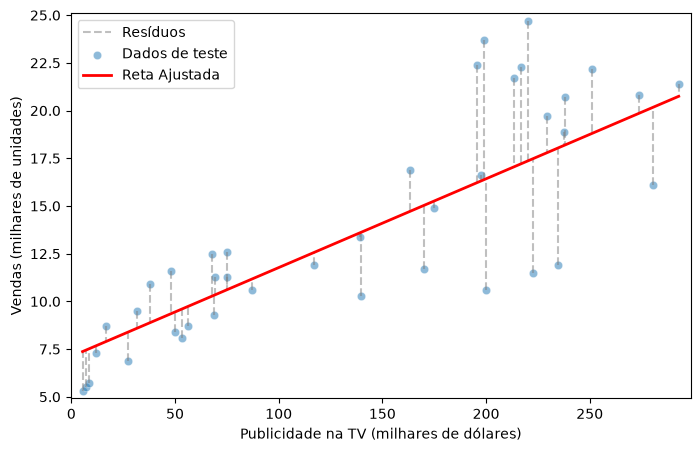

In [43]:
# Ajustes visuais
plt.figure(figsize=(8, 5))
plt.margins(x=0.02, y=0.02)
plt.xlabel("Publicidade na TV (milhares de dólares)")
plt.ylabel("Vendas (milhares de unidades)")

# Adicionando cada linha dos reísudos (IA)
plt.vlines(
    x=x_teste,
    ymin=y_teste,
    ymax=previsao,
    colors="gray",
    linestyles="dashed",
    alpha=0.5,
    label="Resíduos",
)
plt.legend()

# Plota dados de entrada e reta ajustada
eixo = sns.scatterplot(x=x_teste, y=y_teste, alpha=0.5, label="Dados de teste")
sns.lineplot(x=x_teste, y=previsao, color="red", linewidth=2, label="Reta Ajustada");

### Figura 3.1

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [45]:
df = pd.read_csv("data/Advertising.csv", index_col=0)

# Configurações
TAMANHO_TESTE = 0.2
SEMENTE = 42 

# Separa índices para treino e para teste
indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE,
    random_state=SEMENTE
)

In [46]:
# Atribuição de dataframes para teste/treino com base nos índices
df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]
# Atribuindo cada conjunto a uma Série
x_treino = df_treino["TV"]
y_treino = df_treino["vendas"]

x_teste = df_teste["TV"]
y_teste = df_teste["vendas"]

In [47]:
# Atribuindo Pandas/Séries a cada conjunto
X_treino_rlm = df_treino[["TV", "radio"]]
X_teste_rlm = df_teste[["TV", "radio"]]

# Instanciando modelo
modelo_rlm = LinearRegression()

# Treinando modelo
modelo_rlm.fit(X_treino_rlm, y_treino)

# Gerando previsão
previsao_rlm = modelo_rlm.predict(X_teste_rlm)

#### Superfície de Regressão

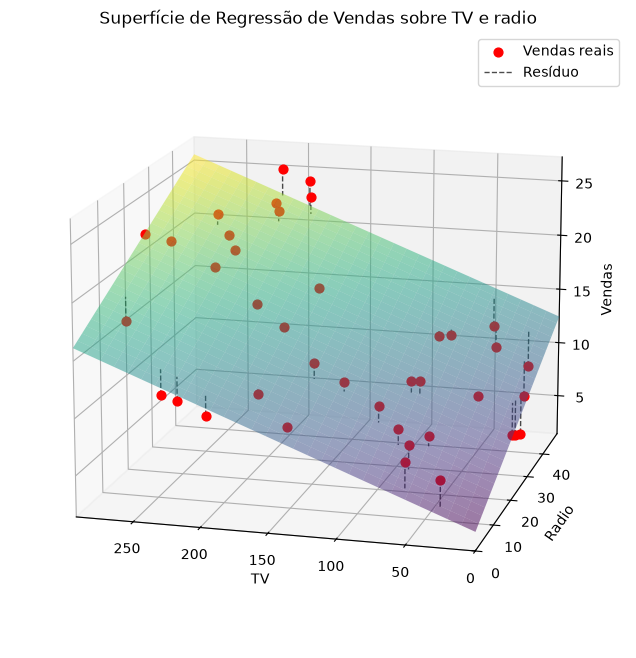

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

max_tv = X_teste_rlm["TV"].max()
max_radio = X_teste_rlm["radio"].max()

tv_range = np.linspace(0, max_tv, 30)
radio_range = np.linspace(0, max_radio, 30)
TV_grid, RADIO_grid = np.meshgrid(tv_range, radio_range)

grid_df = pd.DataFrame({
    "TV": TV_grid.ravel(),
    "radio": RADIO_grid.ravel()
})
Z_grid = modelo_rlm.predict(grid_df).reshape(TV_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    TV_grid, 
    RADIO_grid, 
    Z_grid, 
    cmap=sns.color_palette("viridis", as_cmap=True),
    edgecolor='none',
    alpha=0.5
)

ax.scatter(
    X_teste_rlm["TV"], 
    X_teste_rlm["radio"], 
    y_teste, 
    color='red', 
    s=40, 
    label='Vendas reais',
    depthshade=False
)

for i, (tv, radio, z_actual, z_pred) in enumerate(
    zip(X_teste_rlm["TV"], X_teste_rlm["radio"], y_teste, previsao_rlm)
):
    ax.plot(
        [tv, tv],
        [radio, radio],
        [z_actual, z_pred],
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Resíduo" if i == 0 else None,
    )


# Inverter o eixo X faz com que o 0 do TV e o 0 do Radio se encontrem no vértice frontal
ax.set_xlim(max_tv, 0)
ax.set_ylim(0, max_radio)

# Ângulo de câmera ideal para ver o canto (0,0) de frente
ax.view_init(elev=15, azim=-75)

ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Vendas")
ax.set_title("Superfície de Regressão de Vendas sobre TV e radio")
plt.legend()

plt.show()

#### Desempenho

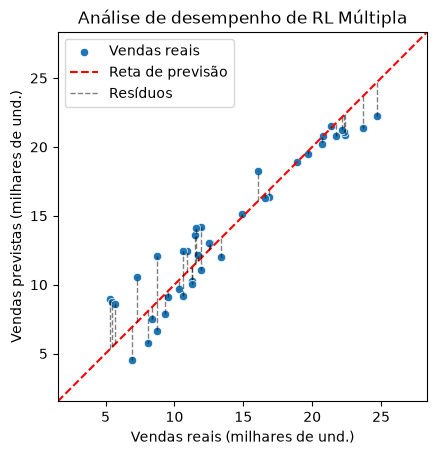

In [49]:
import seaborn as sns

min_val = min(df["vendas"].min(), previsao_rlm.min())
max_val = max(df["vendas"].max(), previsao_rlm.max())

intervalo = [min_val * 0.95, max_val * 1.05]

eixo = sns.scatterplot(x=df["vendas"].loc[indices_teste], y=previsao_rlm, label="Vendas reais")
eixo.plot(intervalo, intervalo, "r--", label="Reta de previsão")

eixo.set(
    title="Análise de desempenho de RL Múltipla",
    xlabel="Vendas reais (milhares de und.)",
    ylabel="Vendas previstas (milhares de und.)",
    xlim=intervalo,
    ylim=intervalo,
    aspect="equal",
)

eixo.vlines(
    x=y_teste,
    ymin=y_teste,
    ymax=previsao_rlm,
    colors="black",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Resíduos",
)
eixo.legend();

### Figura 6.1 

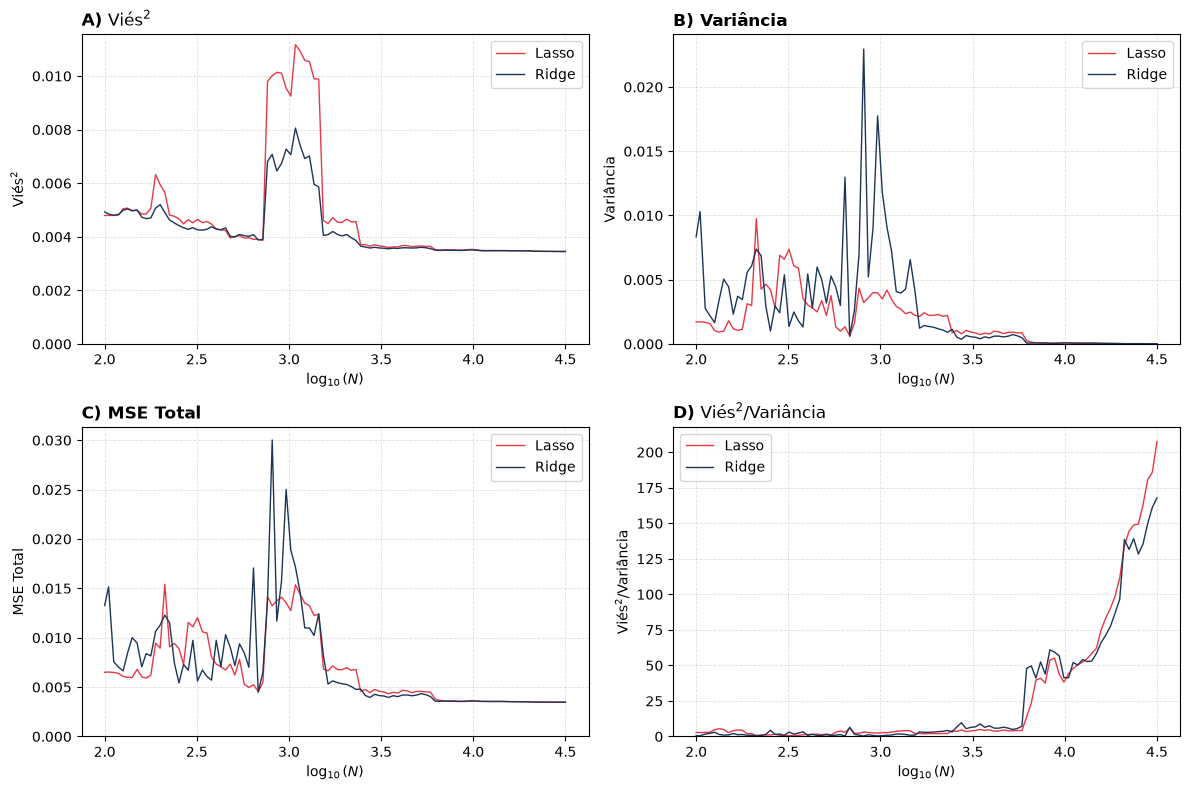

In [50]:
import string
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Carregamento dos dados
df_lasso = pd.read_csv("data/apd_lassocv.csv", index_col=0)
df_ridge = pd.read_csv("data/apd_ridgecv.csv", index_col=0)

# Métrica derivada
for df in (df_lasso, df_ridge):
    df["razao_vies_var"] = df["vies"] / df["variancia"]

x_log = np.log10(df_lasso.index)

modelos = {
    "Lasso": (df_lasso, "#e63946", "-"),
    "Ridge": (df_ridge, "#1d3557", "-")
}

quadrantes = [
    ("vies", r"$\text{Viés}^2$"),
    ("variancia", "Variância"),
    ("mse", "MSE Total"),
    ("razao_vies_var", r"$\text{Viés}^2 / \text{Variância}$"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for idx, (ax, (col, y_lbl)) in enumerate(zip(axes.flat, quadrantes)):
    for nome, (df, cor, ls) in modelos.items():
        ax.tick_params(labelbottom=True)
        ax.plot(x_log, df[col], label=nome, color=cor, linestyle=ls, linewidth=1)

    
    ax.set_ylim(bottom=0)
    ax.set_title(f"{string.ascii_uppercase[idx]}) {y_lbl}", loc="left", weight="bold")
    ax.set_ylabel(y_lbl)
    ax.set_xlabel(r"$\log_{10}(N)$")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()

### Figura 6.2 

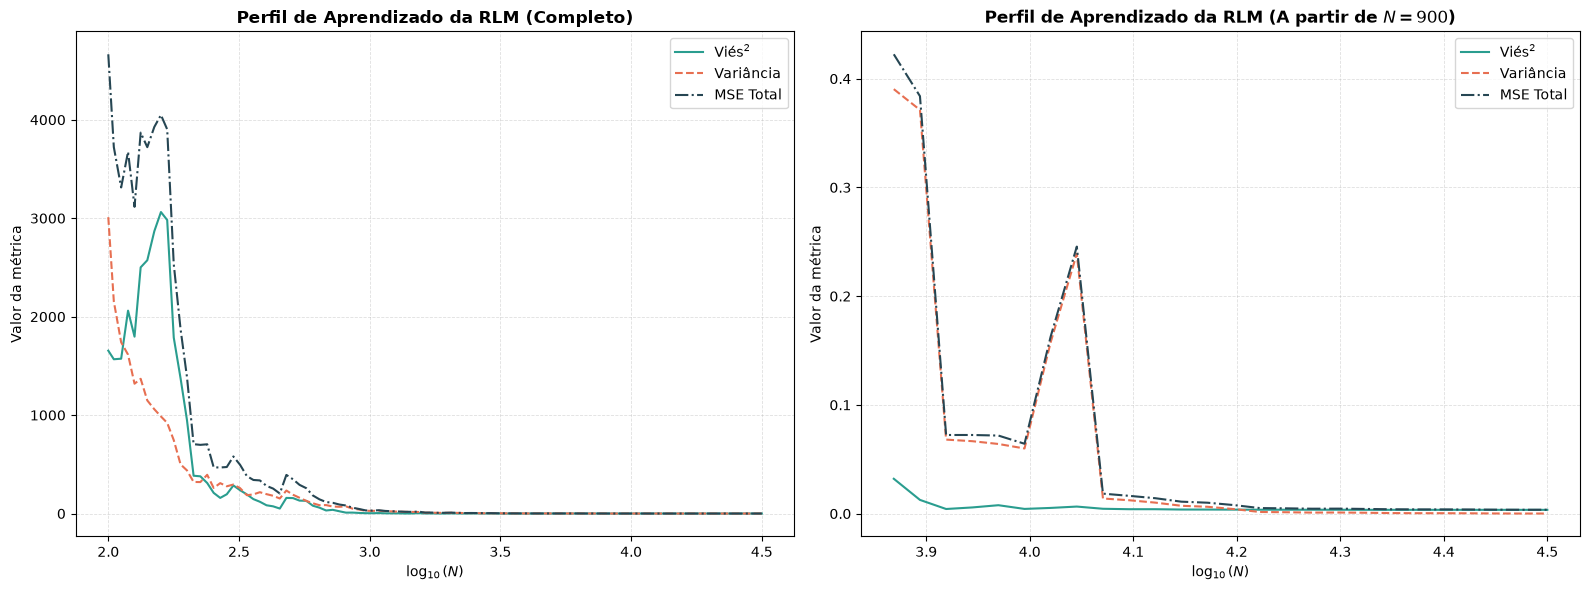

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Carregamento de todos os dados da RLM
df_rlm_full = pd.read_csv("data/apd_linearregression.csv", index_col=0)

# Recorte a partir do índice 900
df_rlm_zoom = df_rlm_full.loc[7000:]

# Métricas com cores e estilos próprios
metricas = {
    "vies": (r"$\text{Viés}^2$", "#2a9d8f", "-"),
    "variancia": ("Variância", "#e76f51", "--"),
    "mse": ("MSE Total", "#264653", "-.")
}

# Criação de figura com 1 linha e 2 colunas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Espaço completo ---
x_log_full = np.log10(df_rlm_full.index)
for col, (rotulo, cor, ls) in metricas.items():
    ax1.plot(x_log_full, df_rlm_full[col], label=rotulo, color=cor, linestyle=ls, linewidth=1.5)

ax1.set_title("Perfil de Aprendizado da RLM (Completo)", weight="bold", fontsize=12)
ax1.set_xlabel(r"$\log_{10}(N)$", fontsize=10)
ax1.set_ylabel("Valor da métrica", fontsize=10)
ax1.legend(frameon=True, loc="best")
ax1.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

# --- Gráfico 2: A partir de 900 instâncias ---
x_log_zoom = np.log10(df_rlm_zoom.index)
for col, (rotulo, cor, ls) in metricas.items():
    ax2.plot(x_log_zoom, df_rlm_zoom[col], label=rotulo, color=cor, linestyle=ls, linewidth=1.5)

ax2.set_title("Perfil de Aprendizado da RLM (A partir de $N = 900$)", weight="bold", fontsize=12)
ax2.set_xlabel(r"$\log_{10}(N)$", fontsize=10)
ax2.set_ylabel("Valor da métrica", fontsize=10)
ax2.legend(frameon=True, loc="best")
ax2.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

plt.tight_layout()
plt.show()

### Figura 6.3

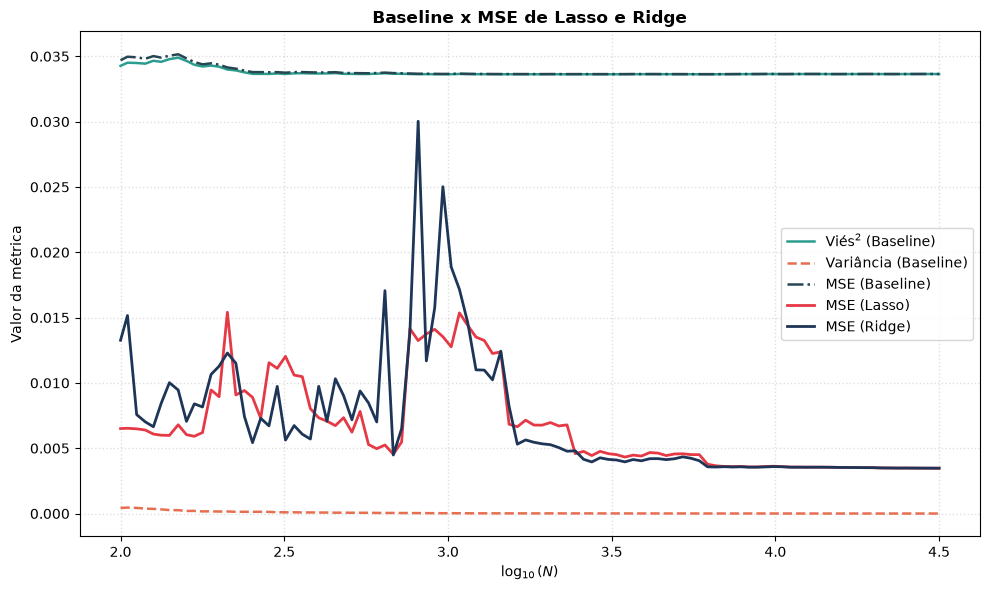

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Carregamento dos dados
df_dum = pd.read_csv("data/apd_dummyregressor.csv", index_col=0)
df_lasso = pd.read_csv("data/apd_lassocv.csv", index_col=0)
df_ridge = pd.read_csv("data/apd_ridgecv.csv", index_col=0)

# Eixo X em escala logarítmica
x_log = np.log10(df_dum.index)

fig, ax = plt.subplots(figsize=(10, 6))

# Métricas do Dummy (Baseline)
metricas_dum = {
    "vies": (r"$\text{Viés}^2$ (Baseline)", "#2a9d8f", "-"),
    "variancia": ("Variância (Baseline)", "#e76f51", "--"),
    "mse": ("MSE (Baseline)", "#264653", "-."),
}

for col, (rotulo, cor, ls) in metricas_dum.items():
    ax.plot(x_log, df_dum[col], label=rotulo, color=cor, linestyle=ls, linewidth=1.8)

# MSE dos modelos Lasso e Ridge
ax.plot(x_log, df_lasso["mse"], label="MSE (Lasso)", color="#e63946", linestyle="-", linewidth=2.0)
ax.plot(x_log, df_ridge["mse"], label="MSE (Ridge)", color="#1d3557", linestyle="-", linewidth=2.0)

ax.set_title("Baseline x MSE de Lasso e Ridge", weight="bold", fontsize=12)
ax.set_xlabel(r"$\log_{10}(N)$", fontsize=10)
ax.set_ylabel("Valor da métrica", fontsize=10)
ax.legend(frameon=True, loc="best")
ax.grid(True, linestyle=":", alpha=0.4, linewidth=1)

plt.tight_layout()
plt.show()

<span id="script-geracao-dataset"></span>
### Script para geração do DataSet

Providenciado pelo Dr. Professor Daniel Roberto Cassar [12].

OBS: O script a seguir gera o arquivo "refractive_index.pkl", entretanto, esse trabalho utiliza "indice_refracao.pkl", uma versão modificada do original, cuja única diferença é a renomeação da coluna "Indice de Refração" para "Indice de Refracao". Essa mudança foi necessária para evitar o conflito de caracteres ao rodar o script anterior (decomposição) no HPC. A fim de evitar confusões, foi mantida apenas a nova versão na pasta `data`. O código utilizado para essa alteração sucede o script a seguir 

In [ ]:
#!/usr/bin/env python3

from pathlib import Path

from glasspy.data import SciGlass

PROJECT_DIR = Path.cwd()
DATA_EXP_DIR = PROJECT_DIR

DATASETNAME = "refractive_index"

MIN_EXEMPLOS = 100


###############################################################################
#                                    Config                                   #
##############################################################################+

DESIRED_PROP = ["RefractiveIndex"]
REMOVED_PROP = SciGlass.available_properties()
for p in DESIRED_PROP:
    REMOVED_PROP.remove(p)

REMOVE_DUPE_DECIMALS = 3

# fmt: off
REMOVED_COMPS = [
    "", "Al2O3+Fe2O3", "MoO3+WO3", "CaO+MgO", "FeO+Fe2O3", "Li2O+Na2O+K2O",
    "Na2O+K2O", "F2O-1", "FemOn", "HF+H2O", "R2O", "R2O3", "RO",
    "RmOn",
]

REMOVED_EL = []
# fmt: on

TREATMENT = {}


###############################################################################
#                            First data collection                            #
##############################################################################+

propconf = {
    "keep": DESIRED_PROP,
    "drop": REMOVED_PROP,
    "must_have_and": DESIRED_PROP,
}

compconf = {
    "acceptable_sum_deviation": 1,
    "final_sum": 100,
    "return_weight": False,
    "dropline": REMOVED_COMPS,
    "drop_compound_with_element": REMOVED_EL,
}

if __name__ == "__main__":
    sg = SciGlass(False, propconf, compconf)

    compounds = sg.data["compounds"].columns

    removed_compounds_oxide = [comp for comp in compounds if "O" not in comp]

    ###############################################################################
    #                                Oxide database                               #
    ##############################################################################+

    compconf_oxide = {
        "acceptable_sum_deviation": 1,
        "final_sum": 100,
        "return_weight": False,
        "dropline": removed_compounds_oxide,
        "drop_compound_with_element": REMOVED_EL,
    }

    sg_final = SciGlass(False, propconf, compconf_oxide)

    sg_final.remove_duplicate_composition(
        scope="compounds",
        decimals=REMOVE_DUPE_DECIMALS,
        aggregator="median",
    )

    df = sg_final.data.copy()

    # remover colunas com baixa representação
    for _ in range(len(df["compounds"].columns)):
        freq = df["compounds"].astype(bool).sum(axis=0)
        if (fmin := freq.min()) < MIN_EXEMPLOS:
            index = freq.tolist().index(fmin)
            col = freq.iloc[index : index + 1].index[0]
            if "Ge" not in col:
                logic = df["compounds"][col] == 0
                df = df.loc[logic]
                df = df.drop(("compounds", col), axis=1)
        else:
            break

    df_final = df["compounds"]
    df_final["Indice de Refração"] = df["property"]["RefractiveIndex"] 

    df_final.to_excel(DATA_EXP_DIR / f"{DATASETNAME}_tratado.xlsx", index=False)
    df_final.to_pickle(f"{DATASETNAME}.pkl.zip")

Modificação do pkl original:

In [ ]:
import pandas as pd

# Carrega pkl original
df = pd.read_pickle("data/refractive_index.pkl")

# Renomeia e salva arquivo modificado
df = df.rename(columns={"Indice de Refração": "Indice de Refracao"})
df.to_pickle("indice_refracao.pkl")

<span id="script-decomposicao"></span>
### Script para decomposição Viés-Variância

O script a seguir foi projetado para ser executado por um HPC (computador de alta performance), visto que requer muito poder computacional para ser executado. O arquivo de job correspondente para rodar o script está disponível neste repositório como `job_decomp.sh`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from mlxtend.evaluate import bias_variance_decomp
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split

# --- CONFIGURACAO ---
SEMENTE = 42
TAMANHO_TESTE = 0.3
N_CPUS = 4  # Alinhado com o cpus-per-task do SLURM

# Importa DF e amostra
df = pd.read_pickle("data/indice_refracao.pkl")
y = df["Indice de Refracao"].to_numpy()
X = df.drop(columns=["Indice de Refracao"]).to_numpy()

# DIVISAO TREINO-TESTE
tamanhos_de_amostra = np.unique(np.logspace(2, 4.5, num=100).astype("int"))
lambdas = np.logspace(-4, 4, num=100)

X_treino_total, X_teste, y_treino_total, y_teste = train_test_split(
    X, y, test_size=TAMANHO_TESTE, random_state=SEMENTE
)

def processar_tamanho(tamanho_amostra):
    X_treino = X_treino_total[:tamanho_amostra]
    y_treino = y_treino_total[:tamanho_amostra]

    # DEFININDO MODELOS PARA BIAS_VARIANCE_DECOMP
    modelos_bench = [
        RidgeCV(alphas=lambdas, cv=5),
        LassoCV(alphas=lambdas, cv=5, max_iter=5_000),
        LinearRegression(),
        DummyRegressor(),
    ]

    resultado_tamanho = {}

    for modelo in modelos_bench:
        nome_classe = modelo.__class__.__name__

        mse, vies, variancia = bias_variance_decomp(
            modelo,
            X_treino, y_treino,
            X_teste, y_teste,
            loss='mse',
            num_rounds=100,
            random_seed=SEMENTE
        )

        resultado_tamanho[nome_classe] = {
            "mse": mse,
            "vies": vies,
            "variancia": variancia
        }

    return resultado_tamanho

# --- EXECUCAO PARALELA ---
resultados = Parallel(n_jobs=N_CPUS, verbose=5)(
    delayed(processar_tamanho)(tamanho)
    for tamanho in tamanhos_de_amostra
)

# --- CONSOLIDAÇÃO E SALVAMENTO ---
modelos = ["RidgeCV", "LassoCV", "LinearRegression", "DummyRegressor"]
chaves = ["mse", "vies", "variancia"]

for modelo in modelos:
    dados_modelo = {chave: [res[modelo][chave] for res in resultados] for chave in chaves}
    df_res = pd.DataFrame(dados_modelo, index=tamanhos_de_amostra)
    df_res.to_csv(f"data/apd_{modelo.lower()}.csv")

<div style="width: 100%; text-align: center; margin-bottom: 20px;">
  <img src="figures/rodape_eleicao.png" alt="Rodapé" style="max-width: 100%; height: auto;">
</div>